# Laguna XS.2 — Cross-Capability Writeability Replication
## v8.2.1b · checkpoint hotfix · full audited cross-capability replication

v6/v7 found that **causal necessity and adaptation plasticity can dissociate**,
and that target-gradient accessibility contains useful information about where
a sparse MoE is writable.

v8 tests whether that result generalizes beyond frontend/UI.

### Default capabilities

The supplied CSV contains five complete capability datasets:

- `frontend` — the original v5/v6/v7 dataset, preserved for comparability;
- `python`;
- `sql`;
- `systems`;
- `algorithms`.

By default v8 runs the **four new capabilities**. Set
`CAPABILITIES_TO_RUN` below to include `frontend` if a full pipeline
replication of the original capability is desired.

For each capability \(q\), v8 estimates:

\[
C_q(E) = \text{causal necessity}
\]

\[
R_q(E) = \text{supervised routing access}
\]

\[
G_q(E) = \text{gradient accessibility}
\]

\[
A_q(E) = \text{actual held-out adaptation}
\]

and tests whether:

\[
\rho(G_q,A_q) > \rho(R_q,A_q),\ \rho(C_q,A_q)
\]

### Leakage discipline

For every capability:

- **selection** constructs causal/routing/gradient selectors;
- **train** is the only adaptation data;
- the 50+50 held-out set is deterministically split into:
  - 25 target + 25 control **atlas validation**;
  - 25 target + 25 control **untouched final test**.
- validation adaptation is used only for population-level \(C/R/G \to A\)
  analysis;
- **no final selector is chosen from validation adaptation**;
- final selector confirmation and parameter-budget curves use the untouched
  final test.

### Causal baseline fairness

Unlike v7's panel-only causal selector, v8 performs a hierarchical causal
search for **every capability**:

1. all 39 sparse layers are causally ablated;
2. the top 8 layers are searched with four randomized expert partitions;
3. leaf experts are individually validated;
4. the best exact causal expert becomes the K=1 causal selector.

### Population analysis

For every capability, 48 experts are sampled independently of all selector
scores:

- one random expert from each of the 39 sparse layers;
- nine additional globally random expert positions.

These 48 experts — and only these 48 — are used for primary population
correlations. Score-selected sentinels are reported separately.

### Final selector comparison

Matched one-expert training, three training-order seeds:

- hierarchical causal;
- global supervised routing;
- global raw target-gradient;
- global target-minus-control gradient.

### Budget curves

Matched K={1,2,4,8} routed-expert budgets for:

- causal;
- routing;
- raw gradient;
- gradient-specific.

All expensive phases checkpoint incrementally and resume from CSV files.

> **v8.2.1 full audit:** exact teacher-forcing alignment checks, stratified held-out split, selection-only selector construction before validation adaptation, greedy causal coalitions, matched K rankings, deterministic seeds, native BF16 merge audit, protocol fingerprinting, and full-cell static validation.

### Adaptation evaluation semantics

v8.2.1 reports **both** post-training realizations:

1. **adapter path (primary, comparable to v6/v7):**
   original Laguna expert output plus the FP32 selected-expert delta;
2. **native BF16 merge (secondary deployment audit):**
   trained FP32 expert masters are cast to BF16, physically merged into
   Laguna's fused expert tensors, and evaluated through the native expert
   backend.

The post-training difference between these two numerical realizations is
recorded, never silently ignored, and is not used as an arbitrary validity
threshold.


### v8.2.1 engineering corrections

This build also fixes several failure modes found during the full audit:

- raw BF16 selective-vs-full logits are **diagnostic only**; exact causal-LM
  token alignment is checked model-independently;
- cheap gradient probes are deterministically interleaved across target topics
  and control source capabilities instead of taking CSV-order prefixes;
- gradient accumulation divides by the **actual accumulation-window size**,
  including the final partial window;
- multi-layer expert surgery and router hooks restore safely after partial
  installation failures;
- K>1 causal budgets use greedy **joint interventions**, not top individual
  causal scores;
- selector rankings are frozen from selection data before validation
  adaptation runs;
- checkpoints are protocol/CSV fingerprinted and critical global tables are
  validated for complete unique `(layer, expert)` coverage;
- post-training adapter results are primary; native BF16 merge behavior is a
  separately recorded deployment audit;
- cross-capability aggregate selector summaries include relative-NLL metrics
  so capabilities with different baseline difficulty are not compared only
  in raw NLL units.

> **v8.2.1b:** fixes the first-row `KeyError: 'layer'` in the 39-layer
> causal sweep and hardens long-run CSV checkpoint loading. The scientific
> protocol hash and results directory are unchanged, so valid v8.2.1
> checkpoints are reused.


## 1 — Install dependencies

In [2]:
# Keep the CUDA-enabled PyTorch build supplied by the instance.
# Do not ask pip to upgrade unrelated numerical packages.
%pip -q install \
  "transformers==5.14.1" \
  "accelerate>=1.10.0" \
  "huggingface_hub>=0.35.0" \
  safetensors pandas numpy psutil tqdm matplotlib

print(
    "Dependency install complete. "
    "If this cell changed Transformers in the current kernel, restart the "
    "kernel once before continuing."
)


Note: you may need to restart the kernel to use updated packages.
Dependency install complete. If this cell changed Transformers in the current kernel, restart the kernel once before continuing.


## 2 — Runtime tuning for AWS g7e.2xlarge

In [3]:
import os

os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["OPENBLAS_NUM_THREADS"] = "6"
os.environ["NUMEXPR_NUM_THREADS"] = "6"
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["MALLOC_ARENA_MAX"] = "4"

os.environ["HF_ENABLE_PARALLEL_LOADING"] = "true"
os.environ["HF_PARALLEL_LOADING_WORKERS"] = "2"
os.environ["HF_XET_NUM_CONCURRENT_RANGE_GETS"] = "8"
os.environ["HF_XET_CHUNK_CACHE_SIZE_BYTES"] = "0"

os.environ["CUDA_MODULE_LOADING"] = "LAZY"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True,max_split_size_mb:512"
)

print("Runtime configured for AWS g7e.2xlarge.")

Runtime configured for AWS g7e.2xlarge.


## 3 — Canonical imports

In [4]:
import os
import gc
import json
import time
import types
import shutil
import hashlib
import platform
import sys
import importlib.util

from pathlib import Path
from contextlib import contextmanager, ExitStack
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

print("Core imports: PASS")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Torch:", torch.__version__)

/home/ec2-user/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Core imports: PASS
NumPy: 2.2.6
Pandas: 2.3.3
Torch: 2.13.0+cu130


## 4 — Dependency verification

In [5]:
from importlib.metadata import version as package_version

required_modules = [
    "torch",
    "transformers",
    "accelerate",
    "huggingface_hub",
    "safetensors",
    "numpy",
    "pandas",
    "psutil",
    "tqdm",
    "matplotlib",
]

missing_modules = [
    name
    for name in required_modules
    if importlib.util.find_spec(
        name
    )
    is None
]

if missing_modules:
    raise ModuleNotFoundError(
        "Missing required modules: "
        + ", ".join(
            missing_modules
        )
        + ". Re-run the install cell once, restart the kernel, then Run All."
    )

transformers_version = package_version(
    "transformers"
)

if (
    transformers_version
    != "5.14.1"
):
    raise RuntimeError(
        "This notebook requires transformers==5.14.1, but the current "
        f"kernel sees {transformers_version}. Run the install cell, restart "
        "the kernel once, then Run All."
    )

if (
    "transformers"
    in sys.modules
):
    loaded_transformers_version = getattr(
        sys.modules[
            "transformers"
        ],
        "__version__",
        None,
    )

    if (
        loaded_transformers_version
        != "5.14.1"
    ):
        raise RuntimeError(
            "Transformers is already imported in this kernel as "
            f"{loaded_transformers_version}, while 5.14.1 is installed on "
            "disk. Restart the kernel once, then Run All."
        )

if (
    importlib.util.find_spec(
        "transformers.conversion_mapping"
    )
    is None
):
    raise ModuleNotFoundError(
        "transformers.conversion_mapping is unavailable. "
        "Re-run the install cell, restart the kernel, then Run All."
    )

print(
    "Dependency verification: PASS"
)

print(
    "Transformers:",
    transformers_version,
)


Dependency verification: PASS
Transformers: 5.14.1


## 5 — Hardware and storage preflight

In [6]:
import os
import shutil
import platform
from pathlib import Path

import psutil
import torch

ram = psutil.virtual_memory()

print("=== Host ===")
print("Python:", platform.python_version())
print("Logical CPUs:", os.cpu_count())
print(f"RAM total:     {ram.total/2**30:.2f} GiB")
print(f"RAM available: {ram.available/2**30:.2f} GiB")

print("\n=== CUDA ===")
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is not visible.")

if torch.cuda.device_count() != 1:
    raise RuntimeError(
        f"This notebook expects exactly one GPU; found {torch.cuda.device_count()}."
    )

props = torch.cuda.get_device_properties(0)

print("GPU:", props.name)
print(f"VRAM: {props.total_memory/2**30:.2f} GiB")
print("Compute capability:", torch.cuda.get_device_capability(0))

if props.total_memory / 2**30 < 88:
    raise RuntimeError("Need a 96GB-class GPU (~89 GiB binary or larger).")

if (os.cpu_count() or 0) < 8:
    print("WARNING: fewer than 8 logical CPUs detected.")

if ram.total / 2**30 < 58:
    print("WARNING: less than a 64-GiB-class host detected.")

roots = [
    Path("/home/ec2-user/workspace"),
    Path("/workspace"),
    Path("/mnt/data"),
    Path("/root"),
    Path("/tmp"),
    Path.cwd(),
]

choices = []
seen_devices = set()

for p in roots:
    try:
        if not p.exists() or not os.access(p, os.W_OK):
            continue
        dev = os.stat(p).st_dev
        if dev in seen_devices:
            continue
        seen_devices.add(dev)
        usage = shutil.disk_usage(p)
        choices.append((usage.free, p, usage))
    except OSError:
        pass

if not choices:
    raise RuntimeError("No writable filesystem found.")

_, WORK_ROOT, disk = max(choices, key=lambda x: x[0])

print("\n=== Storage ===")
print("Work root:", WORK_ROOT)
print(f"Disk free: {disk.free/2**30:.2f} GiB")
print("Hardware preflight: PASS")

=== Host ===
Python: 3.10.12
Logical CPUs: 8
RAM total:     62.27 GiB
RAM available: 59.13 GiB

=== CUDA ===
Torch: 2.13.0+cu130
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 94.97 GiB
Compute capability: (12, 0)

=== Storage ===
Work root: /home/ec2-user/workspace
Disk free: 916.33 GiB
Hardware preflight: PASS


## 6 — Load and validate the v8 cross-capability CSV

Expected schema:

```text
example_id,capability,split,kind,source_capability,topic,difficulty,prompt,reference
```

Each capability must contain exactly:

```text
selection / target   50
selection / control  50
train     / target   50
heldout   / target   50
heldout   / control  50
```

Lookup order:

1. `LAGUNA_V8_CSV`
2. `/home/ec2-user/workspace/laguna_v8_cross_capability_experiment.csv`
3. `/workspace/laguna_v8_cross_capability_experiment.csv`
4. `/mnt/data/laguna_v8_cross_capability_experiment.csv`

In [7]:
csv_candidates = []

if os.environ.get("LAGUNA_V8_CSV"):
    csv_candidates.append(
        Path(os.environ["LAGUNA_V8_CSV"]).expanduser()
    )

csv_candidates.extend([
    Path("/home/ec2-user/workspace/laguna_v8_cross_capability_experiment.csv"),
    Path("/workspace/laguna_v8_cross_capability_experiment.csv"),
    Path("/mnt/data/laguna_v8_cross_capability_experiment.csv"),
])

EXPERIMENT_CSV = next(
    (p.resolve() for p in csv_candidates if p.exists()),
    None,
)

if EXPERIMENT_CSV is None:
    raise FileNotFoundError(
        "laguna_v8_cross_capability_experiment.csv not found. "
        "Set LAGUNA_V8_CSV to its full path."
    )

experiment_df = pd.read_csv(EXPERIMENT_CSV)

required_cols = {
    "example_id",
    "capability",
    "split",
    "kind",
    "source_capability",
    "topic",
    "difficulty",
    "prompt",
    "reference",
}

missing_cols = required_cols - set(experiment_df.columns)

if missing_cols:
    raise ValueError(
        f"Experiment CSV missing columns: {sorted(missing_cols)}"
    )

if experiment_df[
    sorted(
        required_cols
    )
].isna().any().any():
    null_counts = (
        experiment_df[
            sorted(
                required_cols
            )
        ]
        .isna()
        .sum()
    )

    null_counts = (
        null_counts[
            null_counts > 0
        ]
        .to_dict()
    )

    raise RuntimeError(
        f"Experiment CSV contains null required fields: {null_counts}"
    )

for col in [
    "example_id",
    "capability",
    "split",
    "kind",
    "source_capability",
    "topic",
    "difficulty",
    "prompt",
    "reference",
]:
    experiment_df[col] = (
        experiment_df[col]
        .astype(str)
        .str.strip()
    )

experiment_df["capability"] = experiment_df["capability"].str.lower()
experiment_df["split"] = experiment_df["split"].str.lower()
experiment_df["kind"] = experiment_df["kind"].str.lower()
experiment_df["source_capability"] = experiment_df["source_capability"].str.lower()

EXPECTED_CAPABILITIES = [
    "frontend",
    "python",
    "sql",
    "systems",
    "algorithms",
]

if sorted(experiment_df["capability"].unique()) != sorted(EXPECTED_CAPABILITIES):
    raise RuntimeError(
        "Capability set mismatch. Found: "
        + repr(sorted(experiment_df["capability"].unique()))
    )

if experiment_df["example_id"].duplicated().any():
    dupes = experiment_df.loc[
        experiment_df["example_id"].duplicated(),
        "example_id",
    ].head(10).tolist()
    raise RuntimeError(f"Duplicate example IDs: {dupes}")

if (experiment_df["prompt"].str.len() == 0).any():
    raise RuntimeError("Blank prompt detected.")

if (experiment_df["reference"].str.len() == 0).any():
    raise RuntimeError("Blank reference detected.")

expected_counts = {
    ("selection", "target"): 50,
    ("selection", "control"): 50,
    ("train", "target"): 50,
    ("heldout", "target"): 50,
    ("heldout", "control"): 50,
}

for capability in EXPECTED_CAPABILITIES:
    cap = experiment_df[
        experiment_df["capability"] == capability
    ]

    for (split, kind), expected in expected_counts.items():
        actual = len(
            cap[
                (cap["split"] == split)
                & (cap["kind"] == kind)
            ]
        )

        if actual != expected:
            raise RuntimeError(
                f"{capability} {split}/{kind}: "
                f"{actual} != {expected}"
            )

    split_prompts = {
        split: set(
            cap[
                cap["split"] == split
            ]["prompt"]
        )
        for split in ["selection", "train", "heldout"]
    }

    if split_prompts["selection"] & split_prompts["train"]:
        raise RuntimeError(
            f"{capability}: selection/train leakage"
        )

    if split_prompts["selection"] & split_prompts["heldout"]:
        raise RuntimeError(
            f"{capability}: selection/heldout leakage"
        )

    if split_prompts["train"] & split_prompts["heldout"]:
        raise RuntimeError(
            f"{capability}: train/heldout leakage"
        )

    for split in ["selection", "heldout"]:
        target_prompts = set(
            cap[
                (cap["split"] == split)
                & (cap["kind"] == "target")
            ]["prompt"]
        )

        control_prompts = set(
            cap[
                (cap["split"] == split)
                & (cap["kind"] == "control")
            ]["prompt"]
        )

        if target_prompts & control_prompts:
            raise RuntimeError(
                f"{capability}: target/control overlap in {split}"
            )


# New-capability controls are deliberately balanced across the
# four other capability target banks: 12/12/13/13 per split.
for capability in ["python", "sql", "systems", "algorithms"]:
    for split in ["selection", "heldout"]:
        controls = experiment_df[
            (experiment_df["capability"] == capability)
            & (experiment_df["split"] == split)
            & (experiment_df["kind"] == "control")
        ]

        source_counts = (
            controls["source_capability"]
            .value_counts()
            .to_dict()
        )

        if len(source_counts) != 4:
            raise RuntimeError(
                f"{capability} {split}: expected four control sources; "
                f"found {source_counts}"
            )

        if sorted(source_counts.values()) != [12, 12, 13, 13]:
            raise RuntimeError(
                f"{capability} {split}: unbalanced control sources "
                f"{source_counts}"
            )


NEW_CAPABILITIES = [
    "python",
    "sql",
    "systems",
    "algorithms",
]

for capability in NEW_CAPABILITIES:
    cap = experiment_df[
        experiment_df[
            "capability"
        ]
        == capability
    ]

    # Ten target subtopics, five examples each, in every split.
    for split in [
        "selection",
        "train",
        "heldout",
    ]:
        targets = cap[
            (
                cap[
                    "split"
                ]
                == split
            )
            & (
                cap[
                    "kind"
                ]
                == "target"
            )
        ]

        topic_counts = (
            targets[
                "topic"
            ]
            .value_counts()
        )

        if (
            len(
                topic_counts
            )
            != 10
            or not bool(
                (
                    topic_counts
                    == 5
                ).all()
            )
        ):
            raise RuntimeError(
                f"{capability} {split}: expected 10 target topics x 5 rows; "
                f"found {topic_counts.to_dict()}"
            )

        if not bool(
            (
                targets[
                    "source_capability"
                ]
                == capability
            ).all()
        ):
            raise RuntimeError(
                f"{capability} {split}: target source_capability mismatch."
            )

    for split in [
        "selection",
        "heldout",
    ]:
        controls = cap[
            (
                cap[
                    "split"
                ]
                == split
            )
            & (
                cap[
                    "kind"
                ]
                == "control"
            )
        ]

        if bool(
            (
                controls[
                    "source_capability"
                ]
                == capability
            ).any()
        ):
            raise RuntimeError(
                f"{capability} {split}: self-capability control detected."
            )

        # Every imported control must exactly match a target example from
        # its declared source capability and the same split.
        source_target_pairs = {
            source: set(
                zip(
                    experiment_df[
                        (
                            experiment_df[
                                "capability"
                            ]
                            == source
                        )
                        & (
                            experiment_df[
                                "split"
                            ]
                            == split
                        )
                        & (
                            experiment_df[
                                "kind"
                            ]
                            == "target"
                        )
                    ][
                        "prompt"
                    ],
                    experiment_df[
                        (
                            experiment_df[
                                "capability"
                            ]
                            == source
                        )
                        & (
                            experiment_df[
                                "split"
                            ]
                            == split
                        )
                        & (
                            experiment_df[
                                "kind"
                            ]
                            == "target"
                        )
                    ][
                        "reference"
                    ],
                )
            )
            for source in (
                controls[
                    "source_capability"
                ]
                .unique()
            )
        }

        for r in controls.itertuples(
            index=False
        ):
            if (
                r.prompt,
                r.reference,
            ) not in source_target_pairs[
                r.source_capability
            ]:
                raise RuntimeError(
                    f"{capability} {split}: control provenance mismatch "
                    f"for {r.example_id}"
                )

print("Experiment CSV:", EXPERIMENT_CSV)
display(
    experiment_df.groupby(
        ["capability", "split", "kind"]
    ).size().rename("count").reset_index()
)
print("Dataset validation: PASS")

Experiment CSV: /home/ec2-user/workspace/laguna_v8_cross_capability_experiment.csv


,capability,split,kind,count
0,algorithms,heldout,control,50
1,algorithms,heldout,target,50
2,algorithms,selection,control,50
3,algorithms,selection,target,50
4,algorithms,train,target,50
5,frontend,heldout,control,50
6,frontend,heldout,target,50
7,frontend,selection,control,50
8,frontend,selection,target,50
9,frontend,train,target,50


Dataset validation: PASS


## 7 — v8 experiment configuration

In [8]:
# Default: replicate on four capabilities not used as the main v7 target.
CAPABILITIES_TO_RUN = [
    "python",
    "sql",
    "systems",
    "algorithms",
]

# Set this manually if you also want to rerun frontend through v8.
# CAPABILITIES_TO_RUN = [
#     "frontend", "python", "sql", "systems", "algorithms"
# ]

unknown = sorted(
    set(CAPABILITIES_TO_RUN)
    - set(EXPECTED_CAPABILITIES)
)

if unknown:
    raise ValueError(
        f"Unknown capabilities: {unknown}"
    )

CONTROL_PENALTY = 0.75

# Global screening.
GLOBAL_GRAD_PROBE_CASES = 10
GLOBAL_GRAD_CHUNK = 8

# Hierarchical causal search.
CAUSAL_TOP_LAYERS = 8
CAUSAL_SEARCH_SEEDS = [17, 53, 101, 211]
CAUSAL_INITIAL_GROUP_SIZE = 32
CAUSAL_BEAM_WIDTH = 4

# Population + selector sentinels.
POPULATION_N = 48
SELECTOR_TOP_N = 8
V7_ANCHORS = [
    (36, 229),  # frontend causal/read example
    (36, 95),   # frontend gradient-specific/write example
    (30, 229),  # frontend broad-gradient winner
    (29, 194),  # v6 routing winner
    (25, 168),  # v6 gradient winner
    (33, 1),    # v7 routing winner
]

# Precise FP32 gradient geometry.
PRECISE_GRAD_CASES = 12

# Population adaptation atlas.
ATLAS_LR = 1e-5
ATLAS_EPOCHS = 1
ATLAS_MAX_UPDATES = 7
ATLAS_GRAD_ACCUM = 8
ATLAS_ORDER_SEED = 101

# Final confirmation.
CONFIRM_LR = 1e-5
CONFIRM_EPOCHS = 3
CONFIRM_MAX_UPDATES = 50
CONFIRM_GRAD_ACCUM = 8
CONFIRM_ORDER_SEEDS = [11, 23, 47]

# Parameter-budget curve.
RUN_BUDGET_CURVES = True
BUDGET_KS = [1, 2, 4, 8]
BUDGET_SEED = 11

# Deterministic split/panel seeds vary by capability.
BASE_SPLIT_SEED = 8200
BASE_PANEL_SEED = 6200

PROTOCOL_VERSION = "v8.2.1-full-audit"

# Greedy causal coalition budget ranking.
CAUSAL_COALITION_POOL = 16

# Post-training delta-vs-native-merge discrepancy is diagnostic, not a
# validity failure: the two paths intentionally use different expert kernels.
DELTA_MERGE_WARN_NLL = 0.05

RESULTS_ROOT = WORK_ROOT / "laguna_xs2_v8_2_1_cross_capability_full"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Capabilities:", CAPABILITIES_TO_RUN)
print("Results root:", RESULTS_ROOT)

PROTOCOL_CONFIG = {
    "protocol_version": PROTOCOL_VERSION,
    "model_id": "poolside/Laguna-XS.2",
    "base_split_seed": BASE_SPLIT_SEED,
    "base_panel_seed": BASE_PANEL_SEED,
    "run_budget_curves": RUN_BUDGET_CURVES,
    "control_penalty": CONTROL_PENALTY,
    "global_grad_probe_cases": GLOBAL_GRAD_PROBE_CASES,
    "causal_top_layers": CAUSAL_TOP_LAYERS,
    "causal_search_seeds": CAUSAL_SEARCH_SEEDS,
    "causal_initial_group_size": CAUSAL_INITIAL_GROUP_SIZE,
    "causal_beam_width": CAUSAL_BEAM_WIDTH,
    "causal_coalition_pool": CAUSAL_COALITION_POOL,
    "population_n": POPULATION_N,
    "v7_anchors": V7_ANCHORS,
    "selector_top_n": SELECTOR_TOP_N,
    "precise_grad_cases": PRECISE_GRAD_CASES,
    "atlas_lr": ATLAS_LR,
    "atlas_epochs": ATLAS_EPOCHS,
    "atlas_max_updates": ATLAS_MAX_UPDATES,
    "atlas_grad_accum": ATLAS_GRAD_ACCUM,
    "atlas_order_seed": ATLAS_ORDER_SEED,
    "confirm_lr": CONFIRM_LR,
    "confirm_epochs": CONFIRM_EPOCHS,
    "confirm_max_updates": CONFIRM_MAX_UPDATES,
    "confirm_grad_accum": CONFIRM_GRAD_ACCUM,
    "confirm_order_seeds": CONFIRM_ORDER_SEEDS,
    "budget_ks": BUDGET_KS,
    "budget_seed": BUDGET_SEED,
}

PROTOCOL_HASH = hashlib.sha256(
    json.dumps(
        PROTOCOL_CONFIG,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:16]

print("Protocol:", PROTOCOL_VERSION, PROTOCOL_HASH)


def atomic_to_csv(
    df,
    path,
    index=False,
):
    """
    Crash-safe checkpoint write: write a sibling temporary file, fsync it,
    then atomically replace the previous checkpoint.
    """
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = path.with_name(
        path.name
        + ".tmp"
    )

    df.to_csv(
        tmp,
        index=index,
    )

    with open(
        tmp,
        "rb",
    ) as f:
        os.fsync(
            f.fileno()
        )

    os.replace(
        tmp,
        path,
    )

def atomic_write_text(
    path,
    text,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = path.with_name(
        path.name
        + ".tmp"
    )

    with open(
        tmp,
        "w",
        encoding="utf-8",
    ) as f:
        f.write(
            text
        )
        f.flush()
        os.fsync(
            f.fileno()
        )

    os.replace(
        tmp,
        path,
    )

def read_checkpoint_csv(
    path,
    required_columns=None,
    dedupe_keys=None,
):
    """
    Safely read a resumable CSV checkpoint.

    Missing or zero-byte checkpoints return an empty DataFrame with the
    requested schema. Existing checkpoints are schema-checked and may be
    deduplicated by logical keys.

    This helper intentionally does not participate in PROTOCOL_CONFIG or
    PROTOCOL_HASH so valid v8.2.1 checkpoints remain reusable.
    """
    path = Path(path)

    required_columns = list(
        required_columns
        or []
    )

    if not path.exists():
        return pd.DataFrame(
            columns=required_columns
        )

    try:
        df = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(
            columns=required_columns
        )

    missing = (
        set(required_columns)
        - set(df.columns)
    )

    if missing:
        raise RuntimeError(
            f"Checkpoint {path} has an incompatible schema; "
            f"missing columns: {sorted(missing)}"
        )

    if (
        dedupe_keys
        and not df.empty
    ):
        missing_keys = (
            set(dedupe_keys)
            - set(df.columns)
        )

        if missing_keys:
            raise RuntimeError(
                f"Checkpoint {path} is missing dedupe keys: "
                f"{sorted(missing_keys)}"
            )

        df = (
            df.drop_duplicates(
                list(dedupe_keys),
                keep="last",
            )
            .reset_index(drop=True)
        )

    return df


BUILD_HOTFIX = "v8.2.1b-checkpoint-first-row-fix"
print("Notebook build:", BUILD_HOTFIX)


Capabilities: ['python', 'sql', 'systems', 'algorithms']
Results root: /home/ec2-user/workspace/laguna_xs2_v8_2_1_cross_capability_full
Protocol: v8.2.1-full-audit 30bcde3f33e41cbd
Notebook build: v8.2.1b-checkpoint-first-row-fix


## 8 — Resolve official BF16 Laguna XS.2 checkpoint

In [9]:
from huggingface_hub import snapshot_download

MODEL_ID = "poolside/Laguna-XS.2"

default_model_path = (
    Path("/home/ec2-user/workspace/models/Laguna-XS.2")
    if Path("/home/ec2-user/workspace").exists()
    else WORK_ROOT / "models" / "Laguna-XS.2"
)

MODEL_PATH = Path(
    os.environ.get("LAGUNA_BF16_PATH", str(default_model_path))
).expanduser().resolve()

EXPECTED_SHARDS = [
    f"model-{i:05d}-of-00014.safetensors"
    for i in range(1, 15)
]

complete = (
    (MODEL_PATH / "config.json").exists()
    and all((MODEL_PATH / x).exists() for x in EXPECTED_SHARDS)
)

if not complete:
    MODEL_PATH.mkdir(parents=True, exist_ok=True)

    free_gib = shutil.disk_usage(MODEL_PATH).free / 2**30

    if free_gib < 85:
        raise RuntimeError(
            f"Need ~85 GiB free for a fresh BF16 download; found {free_gib:.1f} GiB."
        )

    print("Downloading Laguna XS.2 BF16...")
    snapshot_download(
        repo_id=MODEL_ID,
        local_dir=str(MODEL_PATH),
        allow_patterns=[
            "*.safetensors",
            "*.json",
            "*.py",
            "*.jinja",
            "LICENSE*",
            "README*",
        ],
        max_workers=2,
    )

missing = [x for x in EXPECTED_SHARDS if not (MODEL_PATH / x).exists()]

if missing:
    raise RuntimeError(f"Incomplete checkpoint; missing: {missing}")

sizes = [(x, (MODEL_PATH / x).stat().st_size) for x in EXPECTED_SHARDS]

print("MODEL_PATH:", MODEL_PATH)
print(f"14-shard payload: {sum(n for _, n in sizes)/1e9:.3f} GB")
print("Checkpoint verification: PASS")

MODEL_PATH: /home/ec2-user/workspace/models/Laguna-XS.2
14-shard payload: 66.889 GB
Checkpoint verification: PASS


## 9 — Register Laguna checkpoint conversion mapping

In [10]:
from transformers.conversion_mapping import (
    get_checkpoint_conversion_mapping,
    register_checkpoint_conversion_mapping,
    USER_REGISTERED_MAPPINGS,
)

laguna_mapping = get_checkpoint_conversion_mapping("laguna")

if laguna_mapping is None:
    raise RuntimeError(
        "Transformers does not expose the native Laguna checkpoint conversion mapping."
    )

register_checkpoint_conversion_mapping(
    "laguna",
    laguna_mapping,
    overwrite=True,
)

if "laguna" not in USER_REGISTERED_MAPPINGS:
    raise RuntimeError("Laguna conversion mapping registration failed.")

print("Laguna checkpoint conversion mapping: REGISTERED")
print("Conversion operations:", len(laguna_mapping))

Laguna checkpoint conversion mapping: REGISTERED
Conversion operations: 4


## 10 — Load BF16 model directly onto the RTX PRO 6000

In [11]:
import gc
import time
import torch
import transformers

from transformers import AutoTokenizer, AutoModelForCausalLM

torch.set_num_threads(min(6, os.cpu_count() or 6))

try:
    torch.set_num_interop_threads(2)
except RuntimeError:
    pass

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

print("Transformers:", transformers.__version__)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
    fix_mistral_regex=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

t0 = time.time()

model, loading_info = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
    device_map={"": 0},
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_safetensors=True,
    attn_implementation="sdpa",
    output_loading_info=True,
)

model.eval()
model.config.use_cache = False

for p in model.parameters():
    p.requires_grad_(False)

missing = list(loading_info.get("missing_keys", []))
unexpected = list(loading_info.get("unexpected_keys", []))
mismatched = list(loading_info.get("mismatched_keys", []))

critical = [
    k for k in (missing + unexpected)
    if (
        ".mlp.experts" in k
        or ".mlp.gate" in k
        or "e_score_correction_bias" in k
    )
]

if critical or mismatched:
    raise RuntimeError(
        "Critical checkpoint mismatch.\n"
        f"critical sample: {critical[:12]}\n"
        f"mismatched sample: {mismatched[:12]}"
    )

del loading_info
gc.collect()
torch.cuda.synchronize()

free_b, total_b = torch.cuda.mem_get_info()

print(f"Loaded in {(time.time()-t0)/60:.2f} min")
print(f"GPU allocated: {torch.cuda.memory_allocated()/2**30:.2f} GiB")
print(f"GPU reserved:  {torch.cuda.memory_reserved()/2**30:.2f} GiB")
print(f"GPU peak:      {torch.cuda.max_memory_allocated()/2**30:.2f} GiB")
print(f"Driver free:   {free_b/2**30:.2f} GiB")
print(f"Host RAM available: {psutil.virtual_memory().available/2**30:.2f} GiB")
if hasattr(
    model,
    "get_experts_implementation",
):
    try:
        print(
            "Experts backend:",
            model.get_experts_implementation(),
        )
    except Exception as exc:
        print(
            "Experts backend query unavailable:",
            repr(
                exc
            ),
        )

if any(
    p.requires_grad
    for p in model.parameters()
):
    raise RuntimeError(
        "Base model unexpectedly has trainable parameters after load."
    )

print("BF16 load: PASS")

Transformers: 5.14.1


Loading weights: 100%|███████████████████████| 639/639 [08:26<00:00,  1.26it/s]


Loaded in 8.50 min
GPU allocated: 62.29 GiB
GPU reserved:  81.24 GiB
GPU peak:      63.29 GiB
Driver free:   13.19 GiB
Host RAM available: 58.77 GiB
Experts backend: {'': 'grouped_mm'}
BF16 load: PASS


## 11 — Validate Laguna MoE architecture

In [12]:
cfg = model.config

SPARSE_LAYERS = []

for idx, layer in enumerate(model.model.layers):
    mlp = getattr(layer, "mlp", None)

    if (
        mlp is not None
        and hasattr(mlp, "gate")
        and hasattr(mlp, "experts")
        and hasattr(mlp.experts, "gate_up_proj")
        and hasattr(mlp.experts, "down_proj")
    ):
        SPARSE_LAYERS.append(idx)

assert cfg.hidden_size == 2048
assert cfg.num_hidden_layers == 40
assert cfg.num_experts == 256
assert cfg.num_experts_per_tok == 8
assert cfg.moe_intermediate_size == 512
assert len(SPARSE_LAYERS) == 39

sample_mlp = model.model.layers[SPARSE_LAYERS[0]].mlp

assert tuple(sample_mlp.experts.gate_up_proj.shape) == (256, 1024, 2048)
assert tuple(sample_mlp.experts.down_proj.shape) == (256, 2048, 512)

params_per_expert = (
    sample_mlp.experts.gate_up_proj[0].numel()
    + sample_mlp.experts.down_proj[0].numel()
)

print("Sparse layers:", SPARSE_LAYERS)
print(f"Params / expert: {params_per_expert:,} ({params_per_expert/1e6:.3f}M)")
print("Architecture validation: PASS")

Sparse layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Params / expert: 3,145,728 (3.146M)
Architecture validation: PASS


## 12 — Correct Laguna teacher-forcing format

In [13]:
def chat_prefix_text(prompt):
    messages = [{"role": "user", "content": prompt}]

    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

def parse_case(prompt, reference):
    prefix_text = chat_prefix_text(prompt)

    prefix_ids = tokenizer.encode(
        prefix_text,
        add_special_tokens=False,
    )

    full_ids = tokenizer.encode(
        prefix_text + "\n" + reference,
        add_special_tokens=False,
    )

    start = 0

    for a, b in zip(prefix_ids, full_ids):
        if a != b:
            break
        start += 1

    if start <= 0 or start >= len(full_ids):
        raise RuntimeError(
            f"Could not identify answer boundary for: {prompt!r}"
        )

    return full_ids, start

## 13 — Generic aligned scoring

In [14]:
def build_scoring_batch(df):
    df = df.reset_index(drop=True).copy()

    parsed = [
        parse_case(r.prompt, r.reference)
        for r in df.itertuples(index=False)
    ]

    fulls = [x[0] for x in parsed]
    starts = [x[1] for x in parsed]
    answers = [full[start:] for full, start in zip(fulls, starts)]

    max_prefix = max(starts)
    max_ref = max(len(x) for x in answers)
    batch_size = len(df)
    seq_len = max_prefix + max_ref

    input_ids = torch.full(
        (batch_size, seq_len),
        tokenizer.pad_token_id,
        dtype=torch.long,
    )

    attention_mask = torch.zeros(
        (batch_size, seq_len),
        dtype=torch.long,
    )

    targets = torch.full(
        (batch_size, max_ref),
        -100,
        dtype=torch.long,
    )

    for b, (full, start, ans) in enumerate(zip(fulls, starts, answers)):
        prefix = full[:start]
        prefix_start = max_prefix - len(prefix)

        input_ids[b, prefix_start:max_prefix] = torch.tensor(prefix)
        attention_mask[b, prefix_start:max_prefix] = 1

        input_ids[b, max_prefix:max_prefix+len(ans)] = torch.tensor(ans)
        attention_mask[b, max_prefix:max_prefix+len(ans)] = 1

        targets[b, :len(ans)] = torch.tensor(ans)

    position_ids = attention_mask.cumsum(dim=-1) - 1
    position_ids.clamp_(min=0)

    pred_positions = torch.arange(
        max_prefix - 1,
        max_prefix + max_ref - 1,
        dtype=torch.long,
    )

    return {
        "df": df,
        "input_ids": input_ids.to("cuda:0", non_blocking=True),
        "attention_mask": attention_mask.to("cuda:0", non_blocking=True),
        "position_ids": position_ids.to("cuda:0", non_blocking=True),
        "targets": targets.to("cuda:0", non_blocking=True),
        "pred_positions": pred_positions.to("cuda:0", non_blocking=True),
    }

# `logits_to_keep` is intentionally used here for efficient aligned
# reference-token scoring. On BF16 hardware it need not be bit-identical
# to computing the LM head over the entire sequence and slicing afterward,
# because those are different GEMM shapes. The dedicated sanity cell checks
# POSITION alignment and NLL agreement instead of raw-logit bit equality.
@torch.inference_mode()
def score_batch(batch):
    import torch.nn.functional as F

    out = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        position_ids=batch["position_ids"],
        use_cache=False,
        output_router_logits=False,
        logits_to_keep=batch["pred_positions"],
        return_dict=True,
    )

    logits = out.logits.float()
    targets = batch["targets"]

    losses = F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        targets.reshape(-1),
        ignore_index=-100,
        reduction="none",
    ).reshape(targets.shape)

    valid = targets.ne(-100)

    per_example = (
        (losses * valid).sum(-1)
        / valid.sum(-1).clamp_min(1)
    )

    result = per_example.detach().cpu().numpy()

    del out, logits, losses, per_example

    return result

def assert_teacher_forcing_alignment(
    batch,
    label="batch",
):
    """
    Exact, model-independent off-by-one check.

    For every valid target token y_j, pred_positions[j] must be the input
    position immediately before y_j. This is the actual causal-LM alignment
    invariant; it does not depend on BF16 logit bit-equality.
    """
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    targets = batch["targets"]
    pred_positions = batch["pred_positions"]

    if pred_positions.ndim != 1:
        raise RuntimeError(
            f"{label}: pred_positions must be 1D."
        )

    if targets.shape[1] != pred_positions.numel():
        raise RuntimeError(
            f"{label}: target/pred-position length mismatch: "
            f"{targets.shape[1]} vs {pred_positions.numel()}"
        )

    for b in range(targets.shape[0]):
        valid = targets[b].ne(-100)
        pred = pred_positions[valid]
        target_pos = pred + 1

        if target_pos.numel() == 0:
            raise RuntimeError(
                f"{label}: row {b} has no valid reference tokens."
            )

        if int(target_pos.max().item()) >= input_ids.shape[1]:
            raise RuntimeError(
                f"{label}: row {b} target position exceeds sequence."
            )

        actual_target_tokens = input_ids[
            b,
            target_pos,
        ]

        expected_target_tokens = targets[
            b,
            valid,
        ]

        if not torch.equal(
            actual_target_tokens,
            expected_target_tokens,
        ):
            mismatch = (
                actual_target_tokens
                != expected_target_tokens
            ).nonzero(
                as_tuple=False
            )[0, 0].item()

            raise RuntimeError(
                f"{label}: teacher-forcing token alignment failed "
                f"for row {b}, target index {mismatch}."
            )

        if not bool(
            attention_mask[
                b,
                pred,
            ].bool().all().item()
        ):
            raise RuntimeError(
                f"{label}: prediction position lands on padding in row {b}."
            )

        if not bool(
            attention_mask[
                b,
                target_pos,
            ].bool().all().item()
        ):
            raise RuntimeError(
                f"{label}: target token lands on padding in row {b}."
            )

    return True


# Core intervention, routing, gradient and surgery helpers

In [15]:
from contextlib import contextmanager
import types

def get_sparse_mlp(layer_idx):
    layer_idx = int(layer_idx)

    if layer_idx not in SPARSE_LAYERS:
        raise ValueError(f"Layer {layer_idx} is not sparse.")

    return model.model.layers[layer_idx].mlp

@contextmanager
def gate_intervention(
    layer_idx,
    expert_ids=None,
    zero_all_routed=False,
    renormalize=False,
):
    mlp = get_sparse_mlp(layer_idx)
    gate = mlp.gate
    original_forward = gate.forward

    expert_ids = (
        []
        if expert_ids is None
        else [int(x) for x in expert_ids]
    )

    def patched_forward(self, hidden_states):
        router_logits, routing_weights, selected_experts = (
            original_forward(hidden_states)
        )

        if zero_all_routed:
            routing_weights = torch.zeros_like(routing_weights)

        elif expert_ids:
            ids = torch.tensor(
                expert_ids,
                device=selected_experts.device,
                dtype=selected_experts.dtype,
            )

            keep = ~torch.isin(selected_experts, ids)

            routing_weights = (
                routing_weights
                * keep.to(routing_weights.dtype)
            )

            if renormalize:
                denom = routing_weights.sum(
                    dim=-1,
                    keepdim=True,
                )

                routing_weights = torch.where(
                    denom > 0,
                    routing_weights
                    / denom.clamp_min(1e-12),
                    routing_weights,
                )

        return (
            router_logits,
            routing_weights,
            selected_experts,
        )

    gate.forward = types.MethodType(
        patched_forward,
        gate,
    )

    try:
        yield
    finally:
        gate.forward = original_forward

In [16]:
def summarize_selection_delta(ablated_nll):
    delta = (
        np.asarray(ablated_nll)
        - SELECTION_BASE_NLL
    )

    target_delta = float(
        delta[selection_target_mask].mean()
    )

    control_delta = float(
        delta[selection_control_mask].mean()
    )

    causal_specificity = (
        target_delta
        - CONTROL_PENALTY
        * max(control_delta, 0.0)
    )

    baseline_target = float(
        SELECTION_BASE_NLL[
            selection_target_mask
        ].mean()
    )

    baseline_control = float(
        SELECTION_BASE_NLL[
            selection_control_mask
        ].mean()
    )

    target_relative_delta = (
        target_delta
        / max(
            baseline_target,
            1e-12,
        )
    )

    control_relative_delta = (
        control_delta
        / max(
            baseline_control,
            1e-12,
        )
    )

    causal_relative_specificity = (
        target_relative_delta
        - CONTROL_PENALTY
        * max(
            control_relative_delta,
            0.0,
        )
    )

    return {
        "target_delta_nll": target_delta,
        "control_delta_nll": control_delta,
        "causal_specificity": causal_specificity,
        "target_relative_delta": target_relative_delta,
        "control_relative_delta": control_relative_delta,
        "causal_relative_specificity": causal_relative_specificity,
        "per_example_delta": delta,
    }

def intervention_score(
    layer_idx,
    expert_ids,
    renormalize=False,
):
    with gate_intervention(
        layer_idx,
        expert_ids=expert_ids,
        renormalize=renormalize,
    ):
        nll = score_batch(SELECTION_BATCH)

    return summarize_selection_delta(nll)

def bootstrap_specificity(
    per_example_delta,
    n_boot=5000,
    seed=123,
):
    rng = np.random.default_rng(seed)
    d = np.asarray(
        per_example_delta,
        dtype=np.float64,
    )

    target = d[selection_target_mask]
    control = d[selection_control_mask]

    vals = np.empty(
        int(n_boot),
        dtype=np.float64,
    )

    for i in range(int(n_boot)):
        t = rng.choice(
            target,
            size=len(target),
            replace=True,
        ).mean()

        c = rng.choice(
            control,
            size=len(control),
            replace=True,
        ).mean()

        vals[i] = (
            t
            - CONTROL_PENALTY
            * max(c, 0.0)
        )

    return {
        "ci_2.5": float(np.quantile(vals, 0.025)),
        "ci_97.5": float(np.quantile(vals, 0.975)),
        "p_positive": float((vals > 0).mean()),
    }

In [17]:
def make_training_case(
    prompt,
    reference,
    max_length=1024,
):
    prefix_text = chat_prefix_text(
        prompt
    )

    prefix_ids = tokenizer.encode(
        prefix_text,
        add_special_tokens=False,
    )

    full_ids = tokenizer.encode(
        prefix_text + "\n" + reference,
        add_special_tokens=False,
    )

    if len(full_ids) > max_length:
        raise ValueError(
            f"{len(full_ids)} tokens > {max_length}"
        )

    start = 0

    for a, b in zip(
        prefix_ids,
        full_ids,
    ):
        if a != b:
            break
        start += 1

    if start <= 0 or start >= len(full_ids):
        raise ValueError(
            "Could not identify answer boundary."
        )

    input_ids = torch.tensor(
        full_ids,
        dtype=torch.long,
        device="cuda:0",
    ).unsqueeze(0)

    attention_mask = torch.ones_like(
        input_ids
    )

    pred_positions = torch.arange(
        start - 1,
        len(full_ids) - 1,
        dtype=torch.long,
        device="cuda:0",
    )

    targets = torch.tensor(
        full_ids[start:],
        dtype=torch.long,
        device="cuda:0",
    )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "pred_positions": pred_positions,
        "targets": targets,
    }

In [18]:
def make_supervised_position_mask(
    batch,
):
    mask = torch.zeros_like(
        batch[
            "attention_mask"
        ],
        dtype=torch.bool,
    )

    valid_targets = (
        batch[
            "targets"
        ]
        .ne(
            -100
        )
    )

    positions = batch[
        "pred_positions"
    ]

    for b in range(
        mask.shape[
            0
        ]
    ):
        valid = valid_targets[
            b
        ]

        pos = positions[
            valid
        ]

        mask[
            b,
            pos,
        ] = True

    return mask

@contextmanager
def capture_routing_with_mask(
    batch,
    token_mask,
):
    records = {}
    originals = []

    token_mask_flat = (
        token_mask
        .reshape(
            -1
        )
        .bool()
    )

    try:
        for layer_idx in (
            SPARSE_LAYERS
        ):
            gate = (
                get_sparse_mlp(
                    layer_idx
                )
                .gate
            )

            original = (
                gate.forward
            )

            originals.append(
                (
                    gate,
                    original,
                )
            )

            def make_forward(
                idx,
                original_forward,
            ):
                def patched(
                    self,
                    hidden_states,
                ):
                    (
                        logits,
                        weights,
                        selected,
                    ) = (
                        original_forward(
                            hidden_states
                        )
                    )

                    with torch.no_grad():
                        mask = (
                            token_mask_flat
                        )

                        if (
                            mask.numel()
                            != selected.shape[
                                0
                            ]
                        ):
                            raise RuntimeError(
                                f"Routing mask/token mismatch at layer {idx}: "
                                f"{mask.numel()} vs {selected.shape[0]}"
                            )

                        mask = mask.to(
                            selected.device
                        )

                        ids = (
                            selected[
                                mask
                            ]
                            .reshape(
                                -1
                            )
                            .long()
                        )

                        ws = (
                            weights[
                                mask
                            ]
                            .reshape(
                                -1
                            )
                            .float()
                        )

                        counts = (
                            torch.bincount(
                                ids,
                                minlength=(
                                    cfg.num_experts
                                ),
                            )
                        )

                        wsum = (
                            torch.zeros(
                                cfg.num_experts,
                                device=(
                                    ws.device
                                ),
                                dtype=(
                                    torch.float32
                                ),
                            )
                        )

                        wsum.scatter_add_(
                            0,
                            ids,
                            ws,
                        )

                        records[
                            int(
                                idx
                            )
                        ] = {
                            "tokens": int(
                                mask.sum()
                                .item()
                            ),
                            "counts": (
                                counts
                                .cpu()
                            ),
                            "weight_sums": (
                                wsum
                                .cpu()
                            ),
                        }

                    return (
                        logits,
                        weights,
                        selected,
                    )

                return patched

            gate.forward = (
                types.MethodType(
                    make_forward(
                        layer_idx,
                        original,
                    ),
                    gate,
                )
            )

        yield records

    finally:
        for (
            gate,
            original,
        ) in reversed(
            originals
        ):
            gate.forward = (
                original
            )


In [19]:
def _fused_expert_grad_norms(
    gate_up_grad,
    down_grad,
    chunk_size=8,
):
    if gate_up_grad is None or down_grad is None:
        raise RuntimeError(
            "Expected fused expert gradients, got None."
        )

    n = gate_up_grad.shape[0]
    out = torch.empty(
        n,
        dtype=torch.float64,
        device="cpu",
    )

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)

        gu = gate_up_grad[start:end].float()
        down = down_grad[start:end].float()

        sq = (
            gu.square().sum(dim=(1, 2))
            + down.square().sum(dim=(1, 2))
        )

        out[start:end] = (
            torch.sqrt(sq)
            .double()
            .cpu()
        )

        del gu, down, sq

    return out.numpy()

def _gradient_objective_for_cases(
    cases,
    max_cases,
):
    used = min(
        int(max_cases),
        len(cases),
    )

    if used <= 0:
        raise RuntimeError("No gradient probe cases.")

    for case in cases[:used]:
        with torch.autocast(
            "cuda",
            dtype=torch.bfloat16,
        ):
            out = model(
                input_ids=case["input_ids"],
                attention_mask=case["attention_mask"],
                use_cache=False,
                logits_to_keep=case["pred_positions"],
                return_dict=True,
            )

            logits = out.logits.float()

            loss = F.cross_entropy(
                logits.reshape(-1, logits.shape[-1]),
                case["targets"].reshape(-1),
            ) / used

        loss.backward()

        del out, logits, loss

def scan_layer_fused_gradients(
    layer_idx,
    target_cases,
    control_cases,
    max_cases=8,
):
    mlp = get_sparse_mlp(layer_idx)
    experts = mlp.experts

    gate_up = experts.gate_up_proj
    down = experts.down_proj

    if gate_up.dtype != torch.bfloat16 or down.dtype != torch.bfloat16:
        print(
            "WARNING: fused expert dtype is",
            gate_up.dtype,
            down.dtype,
        )

    for p in model.parameters():
        p.requires_grad_(False)

    gate_up.requires_grad_(True)
    down.requires_grad_(True)

    model.eval()

    try:
        gate_up.grad = None
        down.grad = None

        _gradient_objective_for_cases(
            target_cases,
            max_cases,
        )

        target_norm = _fused_expert_grad_norms(
            gate_up.grad,
            down.grad,
            GLOBAL_GRAD_CHUNK,
        )

        gate_up.grad = None
        down.grad = None
        torch.cuda.empty_cache()

        _gradient_objective_for_cases(
            control_cases,
            max_cases,
        )

        control_norm = _fused_expert_grad_norms(
            gate_up.grad,
            down.grad,
            GLOBAL_GRAD_CHUNK,
        )

        return target_norm, control_norm

    finally:
        gate_up.grad = None
        down.grad = None

        gate_up.requires_grad_(False)
        down.requires_grad_(False)

        gc.collect()
        torch.cuda.empty_cache()

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import types


class SurgicalExpertBank(nn.Module):
    """
    Exact-baseline delta surgery.

    Forward =
        original_frozen_expert_output
        + trainable_selected_expert_output
        - frozen_selected_expert_output

    At initialization:
        trainable_selected == frozen_selected

    therefore:
        delta == 0 exactly

    and the untouched model's original expert kernel remains the base path.
    """

    def __init__(self, selected_pairs):
        super().__init__()

        self.selected_pairs = sorted({
            (int(layer_idx), int(expert_id))
            for layer_idx, expert_id in selected_pairs
        })

        self.params = nn.ParameterDict()
        self.key_map = {}

        self.original_forwards = {}
        self.installed = False

        for layer_idx, expert_id in self.selected_pairs:
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            gu_key = f"L{layer_idx}_E{expert_id}_gu"
            down_key = f"L{layer_idx}_E{expert_id}_down"

            # FP32 master parameters.
            self.params[gu_key] = nn.Parameter(
                experts.gate_up_proj[
                    expert_id
                ]
                .detach()
                .float()
                .clone()
            )

            self.params[down_key] = nn.Parameter(
                experts.down_proj[
                    expert_id
                ]
                .detach()
                .float()
                .clone()
            )

            self.key_map[
                (layer_idx, expert_id)
            ] = (
                gu_key,
                down_key,
            )

        self.to("cuda:0")

    @property
    def trainable_parameter_count(self):
        return sum(
            p.numel()
            for p in self.parameters()
        )

    def install(self):
        if self.installed:
            return

        bank = self

        selected_layers = sorted({
            layer_idx
            for (
                layer_idx,
                _,
            ) in self.selected_pairs
        })

        try:
            for layer_idx in selected_layers:
                experts = get_sparse_mlp(
                    layer_idx
                ).experts

                original_forward = (
                    experts.forward
                )

                self.original_forwards[
                    layer_idx
                ] = original_forward

                selected_ids = sorted({
                    expert_id
                    for (
                        l,
                        expert_id,
                    ) in (
                        self.selected_pairs
                    )
                    if l
                    == layer_idx
                })

                def make_forward(
                    idx,
                    base_experts,
                    original_fn,
                    selected_expert_ids,
                ):
                    def patched_forward(
                        self_experts,
                        hidden_states,
                        top_k_index,
                        top_k_weights,
                    ):
                        # Preserve Laguna's original expert execution as the
                        # frozen base path.
                        base_output = (
                            original_fn(
                                hidden_states,
                                top_k_index,
                                top_k_weights,
                            )
                        )

                        correction = (
                            torch.zeros_like(
                                base_output
                            )
                        )

                        for expert_id in (
                            selected_expert_ids
                        ):
                            (
                                token_idx,
                                top_k_pos,
                            ) = torch.where(
                                top_k_index
                                == expert_id
                            )

                            if (
                                token_idx
                                .numel()
                                == 0
                            ):
                                continue

                            current_state = (
                                hidden_states[
                                    token_idx
                                ]
                            )

                            compute_dtype = (
                                current_state
                                .dtype
                            )

                            (
                                gu_key,
                                down_key,
                            ) = bank.key_map[
                                (
                                    idx,
                                    expert_id,
                                )
                            ]

                            train_gu = (
                                bank.params[
                                    gu_key
                                ]
                                .to(
                                    compute_dtype
                                )
                            )

                            train_down = (
                                bank.params[
                                    down_key
                                ]
                                .to(
                                    compute_dtype
                                )
                            )

                            frozen_gu = (
                                base_experts
                                .gate_up_proj[
                                    expert_id
                                ]
                                .detach()
                            )

                            frozen_down = (
                                base_experts
                                .down_proj[
                                    expert_id
                                ]
                                .detach()
                            )

                            (
                                train_gate,
                                train_up,
                            ) = F.linear(
                                current_state,
                                train_gu,
                            ).chunk(
                                2,
                                dim=-1,
                            )

                            train_hidden = (
                                base_experts
                                .act_fn(
                                    train_gate
                                )
                                * train_up
                            )

                            train_hidden = (
                                F.linear(
                                    train_hidden,
                                    train_down,
                                )
                            )

                            (
                                frozen_gate,
                                frozen_up,
                            ) = F.linear(
                                current_state,
                                frozen_gu,
                            ).chunk(
                                2,
                                dim=-1,
                            )

                            frozen_hidden = (
                                base_experts
                                .act_fn(
                                    frozen_gate
                                )
                                * frozen_up
                            )

                            frozen_hidden = (
                                F.linear(
                                    frozen_hidden,
                                    frozen_down,
                                )
                            )

                            route_weight = (
                                top_k_weights[
                                    token_idx,
                                    top_k_pos,
                                    None,
                                ]
                            )

                            delta = (
                                (
                                    train_hidden
                                    - frozen_hidden
                                )
                                * route_weight
                            ).to(
                                base_output.dtype
                            )

                            correction = (
                                correction
                                .index_add(
                                    0,
                                    token_idx,
                                    delta,
                                )
                            )

                        return (
                            base_output
                            + correction
                        )

                    return patched_forward

                experts.forward = (
                    types.MethodType(
                        make_forward(
                            layer_idx,
                            experts,
                            original_forward,
                            selected_ids,
                        ),
                        experts,
                    )
                )

            self.installed = True

        except Exception:
            # A partially installed multi-layer bank must never be allowed
            # to leak patched forwards into later arms.
            for (
                layer_idx,
                original_forward,
            ) in list(
                self.original_forwards
                .items()
            ):
                get_sparse_mlp(
                    layer_idx
                ).experts.forward = (
                    original_forward
                )

            self.original_forwards.clear()
            self.installed = False
            raise

    def restore(self):
        # Restore even after a partially failed install.
        for (
            layer_idx,
            original_forward,
        ) in list(
            self.original_forwards
            .items()
        ):
            get_sparse_mlp(
                layer_idx
            ).experts.forward = (
                original_forward
            )

        self.original_forwards.clear()
        self.installed = False


In [21]:
def verify_routed_bank_equivalence_pairs(
    pairs,
    probe_df=None,
    tol=1e-5,
):
    pairs = sorted({
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    })

    if not pairs:
        raise ValueError(
            "No expert pairs supplied for equivalence test."
        )

    if probe_df is None:
        probe_df = (
            selection_df
            .head(8)
        )

    batch = build_scoring_batch(
        probe_df
    )

    before = score_batch(
        batch
    )

    bank = SurgicalExpertBank(
        pairs
    )

    try:
        bank.install()

        after = score_batch(
            batch
        )

    finally:
        bank.restore()

        del bank
        del batch

        gc.collect()
        torch.cuda.empty_cache()

    diff = float(
        np.max(
            np.abs(
                before
                - after
            )
        )
    )

    print(
        "Routed bank equivalence",
        pairs,
        "max ΔNLL:",
        diff,
    )

    if diff > float(
        tol
    ):
        raise RuntimeError(
            "SurgicalExpertBank changes outputs before training."
        )

    return diff

def verify_routed_bank_equivalence(
    pair,
    probe_df=None,
    tol=1e-5,
):
    return (
        verify_routed_bank_equivalence_pairs(
            [
                pair
            ],
            probe_df=probe_df,
            tol=tol,
        )
    )


In [22]:
def _configure_grad_checkpointing():
    if hasattr(
        model,
        "enable_input_require_grads",
    ):
        model.enable_input_require_grads()

    try:
        model.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={
                "use_reentrant": False
            }
        )
    except TypeError:
        model.gradient_checkpointing_enable()

def _disable_grad_checkpointing():
    try:
        model.gradient_checkpointing_disable()
    except Exception:
        pass

    if hasattr(
        model,
        "disable_input_require_grads",
    ):
        model.disable_input_require_grads()

def _backprop_bank_cases(
    bank,
    cases,
    max_cases,
):
    used = min(
        int(max_cases),
        len(cases),
    )

    for p in bank.parameters():
        p.grad = None

    for case in cases[:used]:
        with torch.autocast(
            "cuda",
            dtype=torch.bfloat16,
        ):
            out = model(
                input_ids=case["input_ids"],
                attention_mask=case["attention_mask"],
                use_cache=False,
                logits_to_keep=case["pred_positions"],
                return_dict=True,
            )

            logits = out.logits.float()

            loss = F.cross_entropy(
                logits.reshape(-1, logits.shape[-1]),
                case["targets"].reshape(-1),
            ) / used

        loss.backward()

        del out, logits, loss

    grads = []

    for p in bank.parameters():
        if p.grad is None:
            grads.append(
                torch.zeros_like(
                    p,
                    device="cpu",
                    dtype=torch.float32,
                )
            )
        else:
            grads.append(
                p.grad.detach().float().cpu().clone()
            )

    return grads

def precise_gradient_geometry(
    pair,
    target_cases,
    control_cases,
    max_cases=12,
):
    pair = tuple(
        map(
            int,
            pair,
        )
    )

    grad_seed = (
        910000
        + 10000
        * _capability_number(
            CURRENT_CAPABILITY
        )
        + pair[
            0
        ]
        * 257
        + pair[
            1
        ]
    )

    torch.manual_seed(
        grad_seed
    )

    torch.cuda.manual_seed_all(
        grad_seed
    )

    bank = SurgicalExpertBank(
        [
            pair
        ]
    )

    installed = False

    try:
        bank.install()
        installed = True

        for p in (
            model.parameters()
        ):
            p.requires_grad_(
                False
            )

        _configure_grad_checkpointing()

        model.train()
        bank.train()

        target_grads = (
            _backprop_bank_cases(
                bank,
                target_cases,
                max_cases,
            )
        )

        control_grads = (
            _backprop_bank_cases(
                bank,
                control_cases,
                max_cases,
            )
        )

        target_sq = 0.0
        control_sq = 0.0
        dot = 0.0

        for (
            gt,
            gc_,
        ) in zip(
            target_grads,
            control_grads,
        ):
            if not bool(
                torch.isfinite(
                    gt
                ).all()
            ):
                raise RuntimeError(
                    f"Non-finite target gradient for {pair}."
                )

            if not bool(
                torch.isfinite(
                    gc_
                ).all()
            ):
                raise RuntimeError(
                    f"Non-finite control gradient for {pair}."
                )

            target_sq += float(
                torch.sum(
                    gt
                    * gt
                ).item()
            )

            control_sq += float(
                torch.sum(
                    gc_
                    * gc_
                ).item()
            )

            dot += float(
                torch.sum(
                    gt
                    * gc_
                ).item()
            )

        target_l2 = float(
            np.sqrt(
                target_sq
            )
        )

        control_l2 = float(
            np.sqrt(
                control_sq
            )
        )

        cosine = float(
            dot
            / max(
                target_l2
                * control_l2,
                1e-12,
            )
        )

        return {
            "precise_target_grad_l2": (
                target_l2
            ),
            "precise_control_grad_l2": (
                control_l2
            ),
            "precise_grad_dot": dot,
            "precise_grad_cosine": (
                cosine
            ),
            "precise_grad_specific": (
                target_l2
                - CONTROL_PENALTY
                * control_l2
            ),
            "precise_grad_ratio": (
                target_l2
                / (
                    control_l2
                    + 1e-12
                )
            ),
        }

    finally:
        if installed:
            bank.restore()
        else:
            # restore() is robust to a partial failed installation.
            bank.restore()

        _disable_grad_checkpointing()

        model.eval()

        del bank

        gc.collect()
        torch.cuda.empty_cache()


In [23]:
# Same selective reference-token path as score_batch.
@torch.inference_mode()
def score_batch_detailed(batch):
    out = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        position_ids=batch["position_ids"],
        use_cache=False,
        output_router_logits=False,
        logits_to_keep=batch["pred_positions"],
        return_dict=True,
    )

    logits = out.logits.float()
    targets = batch["targets"]

    losses = F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        targets.reshape(-1),
        ignore_index=-100,
        reduction="none",
    ).reshape(targets.shape)

    valid = targets.ne(-100)

    nll = (
        (losses * valid).sum(-1)
        / valid.sum(-1).clamp_min(1)
    )

    preds = logits.argmax(dim=-1)

    correct = (
        preds.eq(targets)
        & valid
    )

    token_acc = (
        correct.sum(-1)
        / valid.sum(-1).clamp_min(1)
    )

    seq_exact = (
        (correct | ~valid)
        .all(dim=-1)
        .float()
    )

    result = {
        "nll": nll.cpu().numpy(),
        "token_acc": token_acc.cpu().numpy(),
        "seq_exact": seq_exact.cpu().numpy(),
    }

    del out, logits, losses, preds

    return result

def evaluate_batch_against_base(
    batch,
    df,
    base_detail,
):
    d = score_batch_detailed(batch)

    target_mask = (
        df["kind"].values == "target"
    )
    control_mask = (
        df["kind"].values == "control"
    )

    target_nll = float(
        d["nll"][target_mask].mean()
    )
    control_nll = float(
        d["nll"][control_mask].mean()
    )

    base_target_nll = float(
        base_detail["nll"][
            target_mask
        ].mean()
    )
    base_control_nll = float(
        base_detail["nll"][
            control_mask
        ].mean()
    )

    target_improvement = (
        base_target_nll - target_nll
    )

    control_improvement = (
        base_control_nll - control_nll
    )

    control_damage = (
        -control_improvement
    )

    utility_score = (
        target_improvement
        - CONTROL_PENALTY
        * max(control_damage, 0.0)
    )

    specific_gain = (
        target_improvement
        - control_improvement
    )

    relative_target_improvement = (
        target_improvement
        / max(
            base_target_nll,
            1e-12,
        )
    )

    relative_control_improvement = (
        control_improvement
        / max(
            base_control_nll,
            1e-12,
        )
    )

    relative_specific_gain = (
        relative_target_improvement
        - relative_control_improvement
    )

    return {
        "base_target_nll": base_target_nll,
        "base_control_nll": base_control_nll,
        "target_nll": target_nll,
        "control_nll": control_nll,
        "target_improvement": float(target_improvement),
        "control_improvement": float(control_improvement),
        "control_damage": float(control_damage),
        "utility_score": float(utility_score),
        "specific_gain": float(specific_gain),
        "relative_target_improvement": float(
            relative_target_improvement
        ),
        "relative_control_improvement": float(
            relative_control_improvement
        ),
        "relative_specific_gain": float(
            relative_specific_gain
        ),
        "target_token_acc": float(
            d["token_acc"][target_mask].mean()
        ),
        "control_token_acc": float(
            d["token_acc"][control_mask].mean()
        ),
        "target_seq_exact": float(
            d["seq_exact"][target_mask].mean()
        ),
        "control_seq_exact": float(
            d["seq_exact"][control_mask].mean()
        ),
        "per_example_nll": d["nll"],
    }

In [24]:
def capture_routed_base_guard(pairs):
    guard = {}

    for layer_idx, expert_id in pairs:
        experts = get_sparse_mlp(
            layer_idx
        ).experts

        guard[(layer_idx, expert_id)] = (
            experts.gate_up_proj[
                expert_id
            ].detach().cpu().clone(),
            experts.down_proj[
                expert_id
            ].detach().cpu().clone(),
        )

    return guard

def assert_routed_base_unchanged(guard):
    for (
        layer_idx,
        expert_id,
    ), (gu0, down0) in guard.items():
        experts = get_sparse_mlp(
            layer_idx
        ).experts

        gu1 = (
            experts.gate_up_proj[
                expert_id
            ].detach().cpu()
        )

        down1 = (
            experts.down_proj[
                expert_id
            ].detach().cpu()
        )

        if not torch.equal(gu0, gu1):
            raise RuntimeError(
                f"Frozen base gate_up changed: "
                f"L{layer_idx}/E{expert_id}"
            )

        if not torch.equal(down0, down1):
            raise RuntimeError(
                f"Frozen base down changed: "
                f"L{layer_idx}/E{expert_id}"
            )

def state_l2(state):
    total = 0.0

    for v in state.values():
        x = v.detach().float()
        total += float(
            torch.sum(x * x).item()
        )

    return float(np.sqrt(total))

def state_delta_l2(before, after):
    total = 0.0

    for k in before:
        d = (
            after[k].detach().float()
            - before[k].detach().float()
        )
        total += float(
            torch.sum(d * d).item()
        )

    return float(np.sqrt(total))

In [25]:
def restore_routed_base_guard(
    guard,
):
    with torch.no_grad():
        for (
            layer_idx,
            expert_id,
        ), (
            gu0,
            down0,
        ) in guard.items():
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            experts.gate_up_proj[
                expert_id
            ].copy_(
                gu0.to(
                    device=(
                        experts
                        .gate_up_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .gate_up_proj
                        .dtype
                    ),
                )
            )

            experts.down_proj[
                expert_id
            ].copy_(
                down0.to(
                    device=(
                        experts
                        .down_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .down_proj
                        .dtype
                    ),
                )
            )

def copy_bank_into_base(
    bank,
    pairs,
):
    with torch.no_grad():
        for (
            layer_idx,
            expert_id,
        ) in pairs:
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            (
                gu_key,
                down_key,
            ) = bank.key_map[
                (
                    layer_idx,
                    expert_id,
                )
            ]

            experts.gate_up_proj[
                expert_id
            ].copy_(
                bank.params[
                    gu_key
                ].detach().to(
                    device=(
                        experts
                        .gate_up_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .gate_up_proj
                        .dtype
                    ),
                )
            )

            experts.down_proj[
                expert_id
            ].copy_(
                bank.params[
                    down_key
                ].detach().to(
                    device=(
                        experts
                        .down_proj
                        .device
                    ),
                    dtype=(
                        experts
                        .down_proj
                        .dtype
                    ),
                )
            )

def verify_native_merge_roundtrip_pairs(
    pairs,
    probe_df=None,
    tol=1e-5,
):
    """
    Initial FP32 bank weights are exact lifts of BF16 expert slices.
    Casting them back to BF16 and merging must therefore be a no-op.
    """
    pairs = sorted({
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    })

    if not pairs:
        raise ValueError(
            "No expert pairs supplied for merge roundtrip."
        )

    if probe_df is None:
        probe_df = (
            selection_df
            .head(8)
        )

    batch = build_scoring_batch(
        probe_df
    )

    before = score_batch(
        batch
    )

    guard = capture_routed_base_guard(
        pairs
    )

    bank = SurgicalExpertBank(
        pairs
    )

    try:
        copy_bank_into_base(
            bank,
            pairs,
        )

        # This is a stronger check than output equivalence: the initial FP32
        # masters came from the frozen BF16 slices, so casting them back to
        # BF16 must reproduce every selected tensor element exactly.
        for (
            layer_idx,
            expert_id,
        ), (
            gu0,
            down0,
        ) in guard.items():
            experts = get_sparse_mlp(
                layer_idx
            ).experts

            gu1 = (
                experts.gate_up_proj[
                    expert_id
                ].detach().cpu()
            )

            down1 = (
                experts.down_proj[
                    expert_id
                ].detach().cpu()
            )

            if not torch.equal(
                gu0,
                gu1,
            ):
                raise RuntimeError(
                    f"Initial native merge changed gate_up values at "
                    f"L{layer_idx}/E{expert_id}."
                )

            if not torch.equal(
                down0,
                down1,
            ):
                raise RuntimeError(
                    f"Initial native merge changed down_proj values at "
                    f"L{layer_idx}/E{expert_id}."
                )

        after = score_batch(
            batch
        )

        diff = float(
            np.max(
                np.abs(
                    before
                    - after
                )
            )
        )

    finally:
        restore_routed_base_guard(
            guard
        )

        assert_routed_base_unchanged(
            guard
        )

        del bank
        del guard
        del batch

        gc.collect()
        torch.cuda.empty_cache()

    print(
        "Native merge roundtrip",
        pairs,
        "max ΔNLL:",
        diff,
    )

    if diff > float(
        tol
    ):
        raise RuntimeError(
            "Initial bank -> BF16 native merge is not an exact no-op."
        )

    return diff

def verify_native_merge_roundtrip(
    pair,
    probe_df=None,
    tol=1e-5,
):
    return (
        verify_native_merge_roundtrip_pairs(
            [
                pair
            ],
            probe_df=probe_df,
            tol=tol,
        )
    )

def train_routed_experts(
    selector,
    pairs,
    order_seed,
    lr,
    epochs,
    max_updates,
    grad_accum,
    eval_batch,
    eval_df,
    eval_base_detail,
):
    """
    Train selected experts through the exact-baseline delta path.

    Two post-training evaluations are recorded:
      * adapter path (primary, comparable to v6/v7);
      * native BF16 merge (secondary deployment/quantization audit).

    Gradient accumulation is averaged by the ACTUAL number of examples in
    each accumulation window, so a final partial window is not underweighted.
    """
    pairs = sorted({
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    })

    if not pairs:
        raise ValueError(
            "At least one expert pair is required."
        )

    if int(
        grad_accum
    ) <= 0:
        raise ValueError(
            "grad_accum must be positive."
        )

    if int(
        epochs
    ) <= 0:
        raise ValueError(
            "epochs must be positive."
        )

    if int(
        max_updates
    ) <= 0:
        raise ValueError(
            "max_updates must be positive."
        )

    run_seed = (
        1000000
        + int(
            order_seed
        )
        + 10000
        * _capability_number(
            CURRENT_CAPABILITY
        )
    )

    torch.manual_seed(
        run_seed
    )

    torch.cuda.manual_seed_all(
        run_seed
    )

    bank = SurgicalExpertBank(
        pairs
    )

    expected_params = (
        len(
            pairs
        )
        * params_per_expert
    )

    if (
        bank.trainable_parameter_count
        != expected_params
    ):
        raise RuntimeError(
            "Trainable parameter budget mismatch."
        )

    guard = capture_routed_base_guard(
        pairs
    )

    optimizer = None
    checkpointing_enabled = False

    history = []
    raw_step = 0
    update_step = 0
    accum_count = 0

    try:
        bank.install()

        for p in (
            model.parameters()
        ):
            p.requires_grad_(
                False
            )

        _configure_grad_checkpointing()
        checkpointing_enabled = True

        # Training mode is needed by Transformers gradient-checkpointing
        # layers. RNG is explicitly seeded above.
        model.train()
        bank.train()

        optimizer = (
            torch.optim.AdamW(
                bank.parameters(),
                lr=float(
                    lr
                ),
                betas=(
                    0.9,
                    0.95,
                ),
                weight_decay=0.01,
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        initial_state = {
            k: (
                v.detach()
                .cpu()
                .clone()
            )
            for (
                k,
                v,
            ) in (
                bank.state_dict()
                .items()
            )
        }

        rng = (
            np.random.default_rng(
                int(
                    order_seed
                )
            )
        )

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        for epoch in range(
            int(
                epochs
            )
        ):
            order = (
                rng.permutation(
                    len(
                        TRAIN_CASES
                    )
                )
                .tolist()
            )

            for (
                position,
                case_idx,
            ) in enumerate(
                order
            ):
                case = TRAIN_CASES[
                    int(
                        case_idx
                    )
                ]

                raw_step += 1
                accum_count += 1

                with torch.autocast(
                    "cuda",
                    dtype=torch.bfloat16,
                ):
                    out = model(
                        input_ids=case[
                            "input_ids"
                        ],
                        attention_mask=case[
                            "attention_mask"
                        ],
                        use_cache=False,
                        logits_to_keep=case[
                            "pred_positions"
                        ],
                        return_dict=True,
                    )

                    logits = (
                        out.logits
                        .float()
                    )

                    loss = (
                        F.cross_entropy(
                            logits.reshape(
                                -1,
                                logits.shape[
                                    -1
                                ],
                            ),
                            case[
                                "targets"
                            ].reshape(
                                -1
                            ),
                        )
                    )

                if not torch.isfinite(
                    loss
                ):
                    raise RuntimeError(
                        f"Non-finite loss in {selector} at raw step {raw_step}."
                    )

                # Accumulate raw per-example gradients, then divide by the
                # ACTUAL window size immediately before the optimizer step.
                loss.backward()

                is_last_example = (
                    epoch
                    == int(
                        epochs
                    )
                    - 1
                    and position
                    == len(
                        order
                    )
                    - 1
                )

                should_step = (
                    accum_count
                    >= int(
                        grad_accum
                    )
                    or is_last_example
                )

                if should_step:
                    if (
                        accum_count
                        <= 0
                    ):
                        raise RuntimeError(
                            "Internal accumulation counter error."
                        )

                    for p in (
                        bank.parameters()
                    ):
                        if (
                            p.grad
                            is not None
                        ):
                            p.grad.div_(
                                float(
                                    accum_count
                                )
                            )

                    grad_norm = (
                        torch.nn.utils.clip_grad_norm_(
                            bank.parameters(),
                            1.0,
                        )
                    )

                    if not bool(
                        torch.isfinite(
                            grad_norm
                        ).item()
                    ):
                        raise RuntimeError(
                            "Non-finite gradient norm during training."
                        )

                    optimizer.step()

                    optimizer.zero_grad(
                        set_to_none=True
                    )

                    update_step += 1

                    history.append({
                        "selector": selector,
                        "budget_k": len(
                            pairs
                        ),
                        "order_seed": int(
                            order_seed
                        ),
                        "lr": float(
                            lr
                        ),
                        "update_step": int(
                            update_step
                        ),
                        "raw_step": int(
                            raw_step
                        ),
                        "accumulated_examples": int(
                            accum_count
                        ),
                        "loss": float(
                            loss.detach()
                            .item()
                        ),
                        "grad_norm": float(
                            grad_norm
                        ),
                    })

                    accum_count = 0

                del (
                    out,
                    logits,
                    loss,
                )

                if (
                    update_step
                    >= int(
                        max_updates
                    )
                ):
                    break

            if (
                update_step
                >= int(
                    max_updates
                )
            ):
                break

        if (
            accum_count
            != 0
        ):
            raise RuntimeError(
                "Training ended with unstepped accumulated gradients."
            )

        if (
            update_step
            <= 0
        ):
            raise RuntimeError(
                "Training arm completed zero optimizer updates."
            )

        model.eval()
        bank.eval()

        adapter_metrics = (
            evaluate_batch_against_base(
                eval_batch,
                eval_df,
                eval_base_detail,
            )
        )

        final_state = {
            k: (
                v.detach()
                .cpu()
                .clone()
            )
            for (
                k,
                v,
            ) in (
                bank.state_dict()
                .items()
            )
        }

        delta_l2 = (
            state_delta_l2(
                initial_state,
                final_state,
            )
        )

        base_l2 = (
            state_l2(
                initial_state
            )
        )

        # Return selected layers to Laguna's native expert forward, then
        # physically merge the trained BF16 slices.
        bank.restore()

        try:
            copy_bank_into_base(
                bank,
                pairs,
            )

            model.eval()

            native_metrics = (
                evaluate_batch_against_base(
                    eval_batch,
                    eval_df,
                    eval_base_detail,
                )
            )

            delta_merge_max_nll_diff = float(
                np.max(
                    np.abs(
                        np.asarray(
                            adapter_metrics[
                                "per_example_nll"
                            ]
                        )
                        - np.asarray(
                            native_metrics[
                                "per_example_nll"
                            ]
                        )
                    )
                )
            )

        finally:
            restore_routed_base_guard(
                guard
            )

        assert_routed_base_unchanged(
            guard
        )

        if (
            delta_merge_max_nll_diff
            > DELTA_MERGE_WARN_NLL
        ):
            print(
                "WARNING:",
                selector,
                "adapter/native max ΔNLL =",
                f"{delta_merge_max_nll_diff:.4f}",
                "(diagnostic only)",
            )

        result = {
            "selector": selector,
            "pairs": pairs,
            "budget_k": len(
                pairs
            ),
            "order_seed": int(
                order_seed
            ),
            "lr": float(
                lr
            ),
            "epochs": int(
                epochs
            ),
            "max_updates": int(
                max_updates
            ),
            "updates": int(
                update_step
            ),
            "trainable_params": int(
                bank.trainable_parameter_count
            ),
            "mean_grad_norm": float(
                np.mean([
                    h[
                        "grad_norm"
                    ]
                    for h in (
                        history
                    )
                ])
            ),
            "parameter_delta_l2": float(
                delta_l2
            ),
            "relative_parameter_delta": float(
                delta_l2
                / max(
                    base_l2,
                    1e-12,
                )
            ),
            "peak_gpu_gib": float(
                torch.cuda.max_memory_allocated()
                / 2**30
            ),
            "delta_merge_max_nll_diff": (
                delta_merge_max_nll_diff
            ),
            **{
                k: v
                for (
                    k,
                    v,
                ) in (
                    adapter_metrics.items()
                )
                if k
                != "per_example_nll"
            },
            "per_example_nll": (
                adapter_metrics[
                    "per_example_nll"
                ]
            ),
        }

        for (
            key,
            value,
        ) in (
            native_metrics.items()
        ):
            if (
                key
                == "per_example_nll"
            ):
                continue

            result[
                f"native_{key}"
            ] = value

        result[
            "native_per_example_nll"
        ] = (
            native_metrics[
                "per_example_nll"
            ]
        )

        result[
            "history"
        ] = history

        return result

    finally:
        # restore() is idempotent and also handles partial installation.
        bank.restore()

        if (
            checkpointing_enabled
        ):
            _disable_grad_checkpointing()

        model.eval()

        # Safe even if native merge/evaluation raised halfway through.
        restore_routed_base_guard(
            guard
        )

        assert_routed_base_unchanged(
            guard
        )

        if (
            optimizer
            is not None
        ):
            del optimizer

        del bank
        del guard

        gc.collect()
        torch.cuda.empty_cache()


# Dependency-free statistics helpers

In [26]:
def _rankdata_average(x):
    """
    Average ranks for ties, implemented with pandas.
    """
    return (
        pd.Series(
            np.asarray(x, dtype=np.float64)
        )
        .rank(
            method="average",
            na_option="keep",
        )
        .to_numpy(dtype=np.float64)
    )

def _pearson_stat(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    if (
        len(x) < 3
        or np.std(x) == 0
        or np.std(y) == 0
    ):
        return np.nan

    x = x - x.mean()
    y = y - y.mean()

    denom = np.sqrt(
        np.sum(x * x)
        * np.sum(y * y)
    )

    if denom <= 0:
        return np.nan

    return float(
        np.sum(x * y)
        / denom
    )

def _spearman_stat(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return np.nan

    return _pearson_stat(
        _rankdata_average(x),
        _rankdata_average(y),
    )

def _kendall_tau_b(x, y):
    """
    Tie-aware Kendall tau-b.
    O(n^2), which is trivial for the 48-expert population panel.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    concordant = 0
    discordant = 0
    ties_x = 0
    ties_y = 0

    n = len(x)

    for i in range(n - 1):
        dx = x[i + 1:] - x[i]
        dy = y[i + 1:] - y[i]

        sx = np.sign(dx)
        sy = np.sign(dy)

        both_nonzero = (
            (sx != 0)
            & (sy != 0)
        )

        products = (
            sx[both_nonzero]
            * sy[both_nonzero]
        )

        concordant += int(
            np.sum(products > 0)
        )

        discordant += int(
            np.sum(products < 0)
        )

        ties_x += int(
            np.sum(
                (sx == 0)
                & (sy != 0)
            )
        )

        ties_y += int(
            np.sum(
                (sy == 0)
                & (sx != 0)
            )
        )

    denom = np.sqrt(
        (
            concordant
            + discordant
            + ties_x
        )
        * (
            concordant
            + discordant
            + ties_y
        )
    )

    if denom <= 0:
        return np.nan

    return float(
        (concordant - discordant)
        / denom
    )

def bootstrap_spearman(
    x,
    y,
    n_boot=5000,
    seed=1234,
):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    y = np.asarray(
        y,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(int(n_boot)):
        idx = rng.integers(
            0,
            len(x),
            size=len(x),
        )

        rho = _spearman_stat(
            x[idx],
            y[idx],
        )

        if np.isfinite(rho):
            vals.append(rho)

    vals = np.asarray(
        vals,
        dtype=np.float64,
    )

    if len(vals) == 0:
        return np.nan, np.nan

    return (
        float(
            np.quantile(
                vals,
                0.025,
            )
        ),
        float(
            np.quantile(
                vals,
                0.975,
            )
        ),
    )

def permutation_p_spearman(
    x,
    y,
    observed,
    n_perm=5000,
    seed=4321,
):
    """
    Two-sided permutation p-value for Spearman correlation.

    Ranks are computed ONCE. Under permutation, y's rank values are permuted
    with observations, so there is no need to call pandas.rank thousands of
    times.
    """
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    y = np.asarray(
        y,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(
            x
        )
        & np.isfinite(
            y
        )
    )

    x = x[
        valid
    ]

    y = y[
        valid
    ]

    if (
        not np.isfinite(
            observed
        )
        or len(
            x
        )
        < 3
    ):
        return np.nan

    xr = _rankdata_average(
        x
    )

    yr = _rankdata_average(
        y
    )

    xr = (
        xr
        - xr.mean()
    )

    yr = (
        yr
        - yr.mean()
    )

    denom = float(
        np.sqrt(
            np.sum(
                xr
                * xr
            )
            * np.sum(
                yr
                * yr
            )
        )
    )

    if (
        denom
        <= 0
    ):
        return np.nan

    rng = np.random.default_rng(
        seed
    )

    extreme = 0

    for _ in range(
        int(
            n_perm
        )
    ):
        perm = rng.permutation(
            len(
                yr
            )
        )

        rho = float(
            np.sum(
                xr
                * yr[
                    perm
                ]
            )
            / denom
        )

        if (
            abs(
                rho
            )
            >= abs(
                observed
            )
        ):
            extreme += 1

    return float(
        (
            extreme
            + 1
        )
        / (
            int(
                n_perm
            )
            + 1
        )
    )


In [27]:
def rank01(x):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    r = _rankdata_average(x)

    if len(r) <= 1:
        return np.zeros_like(r)

    return (
        (r - 1.0)
        / max(
            len(r) - 1.0,
            1.0,
        )
    )

def _linear_residuals(
    y,
    X,
):
    y = np.asarray(
        y,
        dtype=np.float64,
    )

    X = np.asarray(
        X,
        dtype=np.float64,
    )

    # Explicit intercept.
    X_design = np.column_stack([
        np.ones(
            len(X),
            dtype=np.float64,
        ),
        X,
    ])

    beta, *_ = np.linalg.lstsq(
        X_design,
        y,
        rcond=None,
    )

    fitted = (
        X_design
        @ beta
    )

    return (
        y
        - fitted
    )

def partial_rank_corr(
    df,
    x_col,
    y_col,
    controls,
):
    cols = [
        x_col,
        y_col,
        *controls,
    ]

    sub = (
        df[cols]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    if len(sub) < 5:
        return np.nan

    x = rank01(
        sub[x_col].values
    )

    y = rank01(
        sub[y_col].values
    )

    Z = np.column_stack([
        rank01(
            sub[c].values
        )
        for c in controls
    ])

    x_res = _linear_residuals(
        x,
        Z,
    )

    y_res = _linear_residuals(
        y,
        Z,
    )

    return _pearson_stat(
        x_res,
        y_res,
    )

# Capability context preparation

In [28]:
CURRENT_CAPABILITY = None
RESULTS = None

def _capability_number(capability):
    return EXPECTED_CAPABILITIES.index(
        str(capability)
    )

def _stratified_half_split(
    part,
    stratum_col,
    seed,
    left_n=25,
):
    """
    Deterministically split a dataframe into left/right halves while keeping
    each stratum as balanced as integer counts permit.
    """
    part = part.reset_index(drop=True).copy()

    if len(part) != 2 * int(left_n):
        raise RuntimeError(
            f"Expected {2 * int(left_n)} rows; found {len(part)}."
        )

    if stratum_col not in part.columns:
        raise KeyError(
            f"Missing split stratum column: {stratum_col}"
        )

    rng = np.random.default_rng(
        int(seed)
    )

    groups = []

    for key, g in part.groupby(
        stratum_col,
        sort=True,
        dropna=False,
    ):
        idx = g.index.to_numpy().copy()
        rng.shuffle(idx)

        base = len(idx) // 2

        groups.append({
            "key": str(key),
            "idx": idx,
            "take": int(base),
            "size": int(len(idx)),
        })

    already = sum(
        g["take"]
        for g in groups
    )

    deficit = int(left_n) - already

    if deficit < 0:
        raise RuntimeError(
            "Stratified split over-allocated the left half."
        )

    # Odd-sized strata are the natural places to allocate one additional row.
    candidates = [
        j
        for j, g in enumerate(groups)
        if g["take"] < g["size"] - g["take"]
    ]

    rng.shuffle(candidates)

    for j in candidates[:deficit]:
        groups[j]["take"] += 1

    already = sum(
        g["take"]
        for g in groups
    )

    # General fallback for unusual stratum sizes.
    if already < int(left_n):
        remaining_groups = list(range(len(groups)))
        rng.shuffle(remaining_groups)

        while already < int(left_n):
            progressed = False

            for j in remaining_groups:
                if groups[j]["take"] < groups[j]["size"]:
                    groups[j]["take"] += 1
                    already += 1
                    progressed = True

                    if already == int(left_n):
                        break

            if not progressed:
                raise RuntimeError(
                    "Could not complete stratified half split."
                )

    left_idx = []
    right_idx = []

    for g in groups:
        take = g["take"]
        idx = g["idx"]

        left_idx.extend(
            idx[:take].tolist()
        )
        right_idx.extend(
            idx[take:].tolist()
        )

    if len(left_idx) != int(left_n):
        raise RuntimeError(
            f"Left split has {len(left_idx)} rows, expected {left_n}."
        )

    if len(right_idx) != len(part) - int(left_n):
        raise RuntimeError(
            "Right split size mismatch."
        )

    left = (
        part.loc[left_idx]
        .sample(
            frac=1.0,
            random_state=int(seed),
        )
        .reset_index(drop=True)
    )

    right = (
        part.loc[right_idx]
        .sample(
            frac=1.0,
            random_state=int(seed) + 1,
        )
        .reset_index(drop=True)
    )

    return left, right

def _validate_or_write_protocol(results_dir):
    path = (
        Path(results_dir)
        / "protocol_config.json"
    )

    csv_sha256 = hashlib.sha256(
        Path(
            EXPERIMENT_CSV
        ).read_bytes()
    ).hexdigest()

    payload = {
        "protocol_hash": PROTOCOL_HASH,
        "protocol_config": PROTOCOL_CONFIG,
        "experiment_csv": str(EXPERIMENT_CSV),
        "experiment_csv_sha256": csv_sha256,
    }

    if path.exists():
        existing = json.loads(
            path.read_text()
        )

        if (
            existing.get("protocol_hash")
            != PROTOCOL_HASH
            or existing.get(
                "experiment_csv_sha256"
            )
            != csv_sha256
        ):
            raise RuntimeError(
                f"Existing results at {results_dir} were produced by a "
                "different protocol or CSV. Use a fresh RESULTS_ROOT instead "
                "of silently mixing checkpoints."
            )
    else:
        atomic_write_text(
            path,
            json.dumps(
                payload,
                indent=2,
            ),
        )

def _release_previous_capability_context():
    """
    Drop GPU-resident batches/case lists from the previous capability before
    constructing the next one. This avoids transient two-capability VRAM peaks.
    """
    names = [
        "SELECTION_BATCH",
        "VALIDATION_BATCH",
        "FINAL_TEST_BATCH",
        "SELECTION_TARGET_CASES",
        "SELECTION_CONTROL_CASES",
        "TRAIN_CASES",
        "VALIDATION_BASE_DETAIL",
        "FINAL_TEST_BASE_DETAIL",
    ]

    g = globals()

    for name in names:
        if name in g:
            g[
                name
            ] = None

    gc.collect()
    torch.cuda.empty_cache()


def _round_robin_group_order(
    df,
    group_col,
    seed,
):
    """
    Deterministically shuffle within groups and interleave groups round-robin.

    This prevents the cheap gradient probes from accidentally using only the
    first few subtopics/source domains in CSV order.
    """
    df = df.reset_index(
        drop=True
    ).copy()

    if group_col not in df.columns:
        raise KeyError(
            f"Missing probe-order group column: {group_col}"
        )

    rng = np.random.default_rng(
        int(seed)
    )

    queues = []

    for key, g in df.groupby(
        group_col,
        sort=True,
        dropna=False,
    ):
        idx = g.index.to_numpy().copy()
        rng.shuffle(
            idx
        )

        queues.append(
            list(
                map(
                    int,
                    idx,
                )
            )
        )

    rng.shuffle(
        queues
    )

    ordered = []

    while any(
        queues
    ):
        for q in queues:
            if q:
                ordered.append(
                    q.pop()
                )

    if len(ordered) != len(df):
        raise RuntimeError(
            "Probe-order construction lost rows."
        )

    return df.loc[
        ordered
    ].reset_index(
        drop=True
    )


def prepare_capability_context(capability):
    global CURRENT_CAPABILITY
    global RESULTS
    global selection_df
    global train_target_df
    global heldout_df
    global validation_df
    global final_test_df
    global SELECTION_BATCH
    global VALIDATION_BATCH
    global FINAL_TEST_BATCH
    global SELECTION_BASE_NLL
    global VALIDATION_BASE_NLL
    global FINAL_TEST_BASE_NLL
    global selection_target_mask
    global selection_control_mask
    global validation_target_mask
    global validation_control_mask
    global final_test_target_mask
    global final_test_control_mask
    global SELECTION_TARGET_CASES
    global SELECTION_CONTROL_CASES
    global TRAIN_CASES
    global VALIDATION_BASE_DETAIL
    global FINAL_TEST_BASE_DETAIL

    _release_previous_capability_context()

    CURRENT_CAPABILITY = str(
        capability
    )

    cap_df = experiment_df[
        experiment_df["capability"]
        == CURRENT_CAPABILITY
    ].reset_index(
        drop=True
    )

    selection_df = cap_df[
        cap_df["split"]
        == "selection"
    ].reset_index(
        drop=True
    )

    train_target_df = cap_df[
        (
            cap_df["split"]
            == "train"
        )
        & (
            cap_df["kind"]
            == "target"
        )
    ].reset_index(
        drop=True
    )

    heldout_df = cap_df[
        cap_df["split"]
        == "heldout"
    ].reset_index(
        drop=True
    )

    if len(selection_df) != 100:
        raise RuntimeError(
            f"{CURRENT_CAPABILITY}: selection size != 100"
        )

    if len(train_target_df) != 50:
        raise RuntimeError(
            f"{CURRENT_CAPABILITY}: training target size != 50"
        )

    if len(heldout_df) != 100:
        raise RuntimeError(
            f"{CURRENT_CAPABILITY}: heldout size != 100"
        )

    split_seed = (
        BASE_SPLIT_SEED
        + 100
        * _capability_number(
            CURRENT_CAPABILITY
        )
    )

    target_part = heldout_df[
        heldout_df["kind"]
        == "target"
    ].reset_index(
        drop=True
    )

    control_part = heldout_df[
        heldout_df["kind"]
        == "control"
    ].reset_index(
        drop=True
    )

    validation_target, final_target = (
        _stratified_half_split(
            target_part,
            stratum_col="topic",
            seed=split_seed + 1,
            left_n=25,
        )
    )

    control_stratum = (
        "source_capability"
        if control_part[
            "source_capability"
        ].nunique() > 1
        else "topic"
    )

    validation_control, final_control = (
        _stratified_half_split(
            control_part,
            stratum_col=control_stratum,
            seed=split_seed + 2,
            left_n=25,
        )
    )

    validation_df = pd.concat(
        [
            validation_target,
            validation_control,
        ],
        ignore_index=True,
    )

    final_test_df = pd.concat(
        [
            final_target,
            final_control,
        ],
        ignore_index=True,
    )

    validation_df = validation_df.sample(
        frac=1.0,
        random_state=split_seed + 3,
    ).reset_index(
        drop=True
    )

    final_test_df = final_test_df.sample(
        frac=1.0,
        random_state=split_seed + 4,
    ).reset_index(
        drop=True
    )

    if int(
        (
            validation_df["kind"]
            == "target"
        ).sum()
    ) != 25:
        raise RuntimeError(
            "Validation target count mismatch."
        )

    if int(
        (
            validation_df["kind"]
            == "control"
        ).sum()
    ) != 25:
        raise RuntimeError(
            "Validation control count mismatch."
        )

    if int(
        (
            final_test_df["kind"]
            == "target"
        ).sum()
    ) != 25:
        raise RuntimeError(
            "Final-test target count mismatch."
        )

    if int(
        (
            final_test_df["kind"]
            == "control"
        ).sum()
    ) != 25:
        raise RuntimeError(
            "Final-test control count mismatch."
        )

    validation_ids = set(
        validation_df[
            "example_id"
        ]
    )

    final_ids = set(
        final_test_df[
            "example_id"
        ]
    )

    if validation_ids & final_ids:
        raise RuntimeError(
            "Validation/final-test example leakage."
        )

    RESULTS = (
        RESULTS_ROOT
        / CURRENT_CAPABILITY
    )

    RESULTS.mkdir(
        parents=True,
        exist_ok=True,
    )

    _validate_or_write_protocol(
        RESULTS
    )

    atomic_to_csv(
        validation_df,
        RESULTS
        / "atlas_validation_split.csv",
        index=False,
    )

    atomic_to_csv(
        final_test_df,
        RESULTS
        / "untouched_final_test_split.csv",
        index=False,
    )

    # Build GPU scoring batches.
    SELECTION_BATCH = (
        build_scoring_batch(
            selection_df
        )
    )

    VALIDATION_BATCH = (
        build_scoring_batch(
            validation_df
        )
    )

    FINAL_TEST_BATCH = (
        build_scoring_batch(
            final_test_df
        )
    )

    assert_teacher_forcing_alignment(
        SELECTION_BATCH,
        label=(
            f"{CURRENT_CAPABILITY}:selection"
        ),
    )

    assert_teacher_forcing_alignment(
        VALIDATION_BATCH,
        label=(
            f"{CURRENT_CAPABILITY}:validation"
        ),
    )

    assert_teacher_forcing_alignment(
        FINAL_TEST_BATCH,
        label=(
            f"{CURRENT_CAPABILITY}:final_test"
        ),
    )

    SELECTION_BASE_NLL = score_batch(
        SELECTION_BATCH
    )

    VALIDATION_BASE_NLL = score_batch(
        VALIDATION_BATCH
    )

    FINAL_TEST_BASE_NLL = score_batch(
        FINAL_TEST_BATCH
    )

    selection_target_mask = (
        selection_df[
            "kind"
        ].values
        == "target"
    )

    selection_control_mask = (
        selection_df[
            "kind"
        ].values
        == "control"
    )

    validation_target_mask = (
        validation_df[
            "kind"
        ].values
        == "target"
    )

    validation_control_mask = (
        validation_df[
            "kind"
        ].values
        == "control"
    )

    final_test_target_mask = (
        final_test_df[
            "kind"
        ].values
        == "target"
    )

    final_test_control_mask = (
        final_test_df[
            "kind"
        ].values
        == "control"
    )

    selection_target_df = (
        selection_df[
            selection_df[
                "kind"
            ]
            == "target"
        ]
        .reset_index(
            drop=True
        )
    )

    selection_control_df = (
        selection_df[
            selection_df[
                "kind"
            ]
            == "control"
        ]
        .reset_index(
            drop=True
        )
    )

    target_probe_group = (
        "topic"
        if selection_target_df[
            "topic"
        ].nunique() > 1
        else "example_id"
    )

    control_probe_group = (
        "source_capability"
        if selection_control_df[
            "source_capability"
        ].nunique() > 1
        else "example_id"
    )

    selection_target_df = (
        _round_robin_group_order(
            selection_target_df,
            target_probe_group,
            seed=split_seed + 11,
        )
    )

    selection_control_df = (
        _round_robin_group_order(
            selection_control_df,
            control_probe_group,
            seed=split_seed + 12,
        )
    )

    # Persist the exact cheap-gradient probe order for reproducibility.
    atomic_to_csv(
        selection_target_df[
            [
                "example_id",
                "topic",
                "source_capability",
            ]
        ],
        RESULTS
        / "selection_target_probe_order.csv",
        index=False,
    )

    atomic_to_csv(
        selection_control_df[
            [
                "example_id",
                "topic",
                "source_capability",
            ]
        ],
        RESULTS
        / "selection_control_probe_order.csv",
        index=False,
    )

    SELECTION_TARGET_CASES = [
        make_training_case(
            r.prompt,
            r.reference,
            1024,
        )
        for r in (
            selection_target_df
            .itertuples(
                index=False
            )
        )
    ]

    SELECTION_CONTROL_CASES = [
        make_training_case(
            r.prompt,
            r.reference,
            1024,
        )
        for r in (
            selection_control_df
            .itertuples(
                index=False
            )
        )
    ]

    TRAIN_CASES = [
        make_training_case(
            r.prompt,
            r.reference,
            1024,
        )
        for r in (
            train_target_df
            .itertuples(
                index=False
            )
        )
    ]

    VALIDATION_BASE_DETAIL = (
        score_batch_detailed(
            VALIDATION_BATCH
        )
    )

    FINAL_TEST_BASE_DETAIL = (
        score_batch_detailed(
            FINAL_TEST_BATCH
        )
    )

    gc.collect()
    torch.cuda.empty_cache()

    print(
        f"\n=== {CURRENT_CAPABILITY.upper()} ==="
    )

    print(
        "Results:",
        RESULTS,
    )

    print(
        "Selection baseline target/control:",
        float(
            SELECTION_BASE_NLL[
                selection_target_mask
            ].mean()
        ),
        float(
            SELECTION_BASE_NLL[
                selection_control_mask
            ].mean()
        ),
    )

    baseline_target = float(
        SELECTION_BASE_NLL[
            selection_target_mask
        ].mean()
    )

    baseline_control = float(
        SELECTION_BASE_NLL[
            selection_control_mask
        ].mean()
    )

    baseline_ratio = (
        baseline_target
        / max(
            baseline_control,
            1e-12,
        )
    )

    print(
        "Selection target/control baseline NLL ratio:",
        f"{baseline_ratio:.3f}",
    )

    if (
        baseline_ratio < 0.5
        or baseline_ratio > 2.0
    ):
        print(
            "WARNING: target/control baseline difficulty is mismatched. "
            "Absolute specificity metrics are retained for v6/v7 "
            "comparability; relative metrics are also reported."
        )

    print(
        "Validation/final split:",
        "25 target + 25 control each, stratified",
    )

    return {
        "capability": CURRENT_CAPABILITY,
        "split_seed": split_seed,
        "results": str(
            RESULTS
        ),
    }


## Scoring sanity check — run once before the long experiment

In [29]:
prepare_capability_context(
    CAPABILITIES_TO_RUN[0]
)

demo_prefix = chat_prefix_text(
    selection_df.iloc[0][
        "prompt"
    ]
)

print(
    "Teacher-forced boundary:",
    repr(
        (
            demo_prefix
            + "\n"
            + selection_df.iloc[0][
                "reference"
            ]
        )[-100:]
    ),
)

# Exact off-by-one alignment is already checked for every row by
# assert_teacher_forcing_alignment(). The diagnostic below only quantifies
# BF16 numerical differences between two LM-head GEMM shapes.
ids = SELECTION_BATCH[
    "input_ids"
][0:1]

mask = SELECTION_BATCH[
    "attention_mask"
][0:1]

pos = SELECTION_BATCH[
    "position_ids"
][0:1]

keep_all = SELECTION_BATCH[
    "pred_positions"
]

targets_all = SELECTION_BATCH[
    "targets"
][0:1]

valid = targets_all[
    0
].ne(-100)

keep = keep_all[
    valid
]

targets = targets_all[
    :,
    valid,
]

with torch.inference_mode():
    selective_all = model(
        input_ids=ids,
        attention_mask=mask,
        position_ids=pos,
        use_cache=False,
        logits_to_keep=keep_all,
        return_dict=True,
    ).logits.float()

    selective_logits = (
        selective_all[
            :,
            valid,
            :
        ]
    )

    full_all_logits = model(
        input_ids=ids,
        attention_mask=mask,
        position_ids=pos,
        use_cache=False,
        logits_to_keep=0,
        return_dict=True,
    ).logits.float()

    full_sliced_logits = (
        full_all_logits[
            :,
            keep,
            :
        ]
    )

if (
    selective_logits.shape
    != full_sliced_logits.shape
):
    raise RuntimeError(
        "Selective/full valid-logit shape mismatch: "
        f"{tuple(selective_logits.shape)} vs "
        f"{tuple(full_sliced_logits.shape)}"
    )

diff = (
    selective_logits
    - full_sliced_logits
).abs()

max_logit_diff = float(
    diff.max().item()
)

mean_logit_diff = float(
    diff.mean().item()
)

selective_loss = (
    F.cross_entropy(
        selective_logits.reshape(
            -1,
            selective_logits.shape[-1],
        ),
        targets.reshape(-1),
        reduction="mean",
    )
)

full_loss = (
    F.cross_entropy(
        full_sliced_logits.reshape(
            -1,
            full_sliced_logits.shape[-1],
        ),
        targets.reshape(-1),
        reduction="mean",
    )
)

nll_abs_diff = abs(
    float(
        selective_loss.item()
    )
    - float(
        full_loss.item()
    )
)

print(
    "Selective/full BF16 diagnostic:"
)

print(
    "  max |logit Δ|   =",
    max_logit_diff,
)

print(
    "  mean |logit Δ|  =",
    mean_logit_diff,
)

print(
    "  |mean NLL Δ|    =",
    nll_abs_diff,
)

# Numerical differences between the selective and full LM-head GEMM shapes
# are diagnostic only on BF16 hardware. Exact token POSITION correctness is
# enforced independently by assert_teacher_forcing_alignment().
if not np.isfinite(
    nll_abs_diff
):
    raise RuntimeError(
        "Selective/full BF16 diagnostic produced a non-finite NLL."
    )

if nll_abs_diff > 0.10:
    print(
        "WARNING: selective/full mean NLL differs by",
        f"{nll_abs_diff:.6f}.",
        "Token alignment is exact; this is retained as a BF16 numerical",
        "diagnostic and does not abort the experiment.",
    )

del (
    selective_all,
    selective_logits,
    full_all_logits,
    full_sliced_logits,
    selective_loss,
    full_loss,
    diff,
)

gc.collect()
torch.cuda.empty_cache()

verify_routed_bank_equivalence(
    (36, 229),
    tol=1e-5,
)

verify_routed_bank_equivalence_pairs(
    [
        (36, 229),
        (29, 194),
    ],
    probe_df=selection_df.head(
        4
    ),
    tol=1e-5,
)

verify_native_merge_roundtrip_pairs(
    [
        (36, 229),
        (29, 194),
    ],
    probe_df=selection_df.head(
        4
    ),
    tol=1e-5,
)

print(
    "Global scoring/surgery sanity: PASS"
)



=== PYTHON ===
Results: /home/ec2-user/workspace/laguna_xs2_v8_2_1_cross_capability_full/python
Selection baseline target/control: 0.9074313640594482 2.6408753395080566
Selection target/control baseline NLL ratio: 0.344
Validation/final split: 25 target + 25 control each, stratified
Teacher-forced boundary: 'only the elements divisible by 2.\n</user>\n<assistant>\n</think>\n[x + 1 for x in nums_0 if x % 2 == 0]'
Selective/full BF16 diagnostic:
  max |logit Δ|   = 0.25
  mean |logit Δ|  = 0.0035917644854635
  |mean NLL Δ|    = 0.006237626075744629
Routed bank equivalence [(36, 229)] max ΔNLL: 0.0
Routed bank equivalence [(29, 194), (36, 229)] max ΔNLL: 0.0
Native merge roundtrip [(29, 194), (36, 229)] max ΔNLL: 0.0
Global scoring/surgery sanity: PASS


# Per-capability phase functions

In [30]:
def _validate_global_pair_table(
    df,
    label,
):
    expected = (
        len(SPARSE_LAYERS)
        * cfg.num_experts
    )

    if len(df) != expected:
        raise RuntimeError(
            f"{label}: row count {len(df)} != {expected}."
        )

    if df[
        [
            "layer",
            "expert",
        ]
    ].duplicated().any():
        raise RuntimeError(
            f"{label}: duplicate (layer, expert) rows."
        )

    expected_layers = set(
        map(
            int,
            SPARSE_LAYERS,
        )
    )

    found_layers = set(
        df[
            "layer"
        ].astype(int)
    )

    if found_layers != expected_layers:
        raise RuntimeError(
            f"{label}: sparse-layer coverage mismatch."
        )

    counts = (
        df.groupby(
            "layer"
        )[
            "expert"
        ]
        .nunique()
    )

    if not bool(
        (
            counts
            == int(
                cfg.num_experts
            )
        ).all()
    ):
        raise RuntimeError(
            f"{label}: one or more layers do not contain "
            f"{cfg.num_experts} unique experts."
        )

    return True


def run_global_routing_screen():
    path = RESULTS / "global_routing_screen.csv"

    df = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "expert",
            "selection_supervised_positions",
            "selection_supervised_selected_hits",
            "selection_supervised_selected_rate",
            "selection_supervised_routing_mass",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    if not df.empty:
        try:
            _validate_global_pair_table(
                df,
                "global routing checkpoint",
            )
            return df

        except RuntimeError as exc:
            print(
                "Ignoring invalid routing checkpoint:",
                exc,
            )

    selection_target_df = selection_df[
        selection_df["kind"] == "target"
    ].reset_index(
        drop=True
    )

    batch = build_scoring_batch(
        selection_target_df
    )

    supervised_mask = (
        make_supervised_position_mask(
            batch
        )
    )

    with capture_routing_with_mask(
        batch,
        supervised_mask,
    ) as routing_records:
        _ = score_batch(
            batch
        )

    rows = []

    for layer_idx in SPARSE_LAYERS:
        rec = routing_records[
            int(layer_idx)
        ]

        tokens = max(
            1,
            rec[
                "tokens"
            ],
        )

        for expert_id in range(
            cfg.num_experts
        ):
            rows.append({
                "layer": int(
                    layer_idx
                ),
                "expert": int(
                    expert_id
                ),
                "selection_supervised_positions": int(
                    rec[
                        "tokens"
                    ]
                ),
                "selection_supervised_selected_hits": int(
                    rec[
                        "counts"
                    ][
                        expert_id
                    ].item()
                ),
                "selection_supervised_selected_rate": float(
                    rec[
                        "counts"
                    ][
                        expert_id
                    ].item()
                )
                / tokens,
                "selection_supervised_routing_mass": float(
                    rec[
                        "weight_sums"
                    ][
                        expert_id
                    ].item()
                )
                / tokens,
            })

    df = pd.DataFrame(
        rows
    ).sort_values(
        [
            "selection_supervised_routing_mass",
            "selection_supervised_selected_rate",
        ],
        ascending=False,
    ).reset_index(
        drop=True
    )

    df[
        "routing_rank"
    ] = (
        np.arange(
            len(
                df
            )
        )
        + 1
    )

    _validate_global_pair_table(
        df,
        "global routing result",
    )

    atomic_to_csv(
        df,
        path,
        index=False,
    )

    del batch
    gc.collect()
    torch.cuda.empty_cache()

    return df

In [31]:
def run_global_gradient_screen():
    path = RESULTS / "global_gradient_screen.csv"

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "expert",
            "global_target_grad_bf16",
            "global_control_grad_bf16",
            "global_grad_specific_bf16",
            "global_grad_ratio_bf16",
            "scan_peak_gpu_gib",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    completed_layers = set()

    if not partial.empty:
        counts = partial.groupby(
            "layer"
        ).size()

        completed_layers = {
            int(layer)
            for layer, count in counts.items()
            if int(count) == cfg.num_experts
        }

    print(
        "Global gradient completed layers:",
        len(completed_layers),
        "/",
        len(SPARSE_LAYERS),
    )

    for layer_idx in tqdm(
        SPARSE_LAYERS,
        desc=f"{CURRENT_CAPABILITY}: global gradient",
    ):
        layer_idx = int(layer_idx)

        if layer_idx in completed_layers:
            continue

        torch.cuda.reset_peak_memory_stats()

        target_norm, control_norm = (
            scan_layer_fused_gradients(
                layer_idx,
                SELECTION_TARGET_CASES,
                SELECTION_CONTROL_CASES,
                max_cases=GLOBAL_GRAD_PROBE_CASES,
            )
        )

        layer_rows = []

        for expert_id in range(
            cfg.num_experts
        ):
            gt = float(
                target_norm[
                    expert_id
                ]
            )
            gc_ = float(
                control_norm[
                    expert_id
                ]
            )

            layer_rows.append({
                "layer": layer_idx,
                "expert": int(expert_id),
                "global_target_grad_bf16": gt,
                "global_control_grad_bf16": gc_,
                "global_grad_specific_bf16": (
                    gt
                    - CONTROL_PENALTY
                    * gc_
                ),
                "global_grad_ratio_bf16": (
                    gt
                    / (gc_ + 1e-12)
                ),
                "scan_peak_gpu_gib": float(
                    torch.cuda.max_memory_allocated()
                    / 2**30
                ),
            })

        if partial.empty:
            partial = pd.DataFrame(
                layer_rows
            )
        else:
            partial = pd.concat(
                [
                    partial[
                        partial["layer"]
                        != layer_idx
                    ],
                    pd.DataFrame(
                        layer_rows
                    ),
                ],
                ignore_index=True,
            )

        atomic_to_csv(
            partial,
            path,
            index=False,
        )

    df = pd.read_csv(path)

    _validate_global_pair_table(
        df,
        "global gradient result",
    )

    if not bool(
        np.isfinite(
            df[
                [
                    "global_target_grad_bf16",
                    "global_control_grad_bf16",
                    "global_grad_specific_bf16",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ):
        raise RuntimeError(
            "Global gradient screen contains non-finite scores."
        )

    return df

In [32]:
def run_layer_causal_sweep():
    path = RESULTS / "layer_causal_scores.csv"

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
        dedupe_keys=[
            "layer",
        ],
    )

    valid_layers = set(
        map(
            int,
            SPARSE_LAYERS,
        )
    )

    if not partial.empty:
        found_layers = set(
            partial[
                "layer"
            ].astype(int)
        )

        invalid_layers = (
            found_layers
            - valid_layers
        )

        if invalid_layers:
            raise RuntimeError(
                "Layer-causal checkpoint contains non-sparse layers: "
                f"{sorted(invalid_layers)}"
            )

    completed = set(
        partial[
            "layer"
        ].astype(int)
        .tolist()
    )

    for layer_idx in tqdm(
        SPARSE_LAYERS,
        desc=f"{CURRENT_CAPABILITY}: 39-layer causal sweep",
    ):
        layer_idx = int(
            layer_idx
        )

        if layer_idx in completed:
            continue

        with gate_intervention(
            layer_idx,
            zero_all_routed=True,
        ):
            nll = score_batch(
                SELECTION_BATCH
            )

        m = summarize_selection_delta(
            nll
        )

        row_df = pd.DataFrame([
            {
                "layer": layer_idx,
                "target_delta_nll": m[
                    "target_delta_nll"
                ],
                "control_delta_nll": m[
                    "control_delta_nll"
                ],
                "causal_specificity": m[
                    "causal_specificity"
                ],
            }
        ])

        if partial.empty:
            partial = row_df
        else:
            partial = pd.concat(
                [
                    partial[
                        partial[
                            "layer"
                        ].astype(int)
                        != layer_idx
                    ],
                    row_df,
                ],
                ignore_index=True,
            )

        atomic_to_csv(
            partial,
            path,
            index=False,
        )

        completed.add(
            layer_idx
        )

    df = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
        dedupe_keys=[
            "layer",
        ],
    )

    if len(df) != len(
        SPARSE_LAYERS
    ):
        raise RuntimeError(
            f"Layer causal sweep incomplete: "
            f"{len(df)} != {len(SPARSE_LAYERS)}"
        )

    if set(
        df[
            "layer"
        ].astype(int)
    ) != valid_layers:
        raise RuntimeError(
            "Layer causal sweep coverage mismatch."
        )

    if not bool(
        np.isfinite(
            df[
                [
                    "target_delta_nll",
                    "control_delta_nll",
                    "causal_specificity",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ):
        raise RuntimeError(
            "Layer causal sweep contains non-finite scores."
        )

    return (
        df.sort_values(
            "causal_specificity",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

def hierarchical_expert_search(
    layer_idx,
    seed,
    initial_group_size=32,
    beam_width=4,
):
    rng = np.random.default_rng(
        int(seed)
    )

    order = rng.permutation(
        cfg.num_experts
    ).tolist()

    frontier = [
        order[
            i:i + initial_group_size
        ]
        for i in range(
            0,
            len(order),
            initial_group_size,
        )
    ]

    history = []
    level = 0

    while frontier:
        current = []

        for group in tqdm(
            frontier,
            desc=(
                f"{CURRENT_CAPABILITY}: "
                f"L{int(layer_idx)} seed={int(seed)} level={int(level)}"
            ),
            leave=False,
        ):
            m = intervention_score(
                int(layer_idx),
                group,
            )

            rec = {
                "layer": int(layer_idx),
                "seed": int(seed),
                "level": int(level),
                "group_size": int(
                    len(group)
                ),
                "experts_json": json.dumps(
                    list(
                        map(
                            int,
                            group,
                        )
                    )
                ),
                "target_delta_nll": m[
                    "target_delta_nll"
                ],
                "control_delta_nll": m[
                    "control_delta_nll"
                ],
                "causal_specificity": m[
                    "causal_specificity"
                ],
            }

            history.append(
                rec
            )
            current.append(
                rec
            )

        current.sort(
            key=lambda x: x[
                "causal_specificity"
            ],
            reverse=True,
        )

        keep = current[
            :int(beam_width)
        ]

        if all(
            x["group_size"] == 1
            for x in keep
        ):
            break

        nxt = []

        for rec in keep:
            g = json.loads(
                rec[
                    "experts_json"
                ]
            )

            if len(g) == 1:
                nxt.append(g)
            else:
                mid = len(g) // 2
                nxt.extend([
                    g[:mid],
                    g[mid:],
                ])

        frontier = [
            x
            for x in nxt
            if x
        ]

        level += 1

    return pd.DataFrame(
        history
    )

def run_hierarchical_causal_search(
    layer_df,
):
    history_path = (
        RESULTS
        / "hierarchical_group_history.csv"
    )

    history_df = read_checkpoint_csv(
        history_path,
        required_columns=[
            "layer",
            "seed",
            "level",
            "group_size",
            "experts_json",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
    )

    candidate_layers = (
        layer_df.head(
            CAUSAL_TOP_LAYERS
        )["layer"]
        .astype(int)
        .tolist()
    )

    completed = set()

    if not history_df.empty:
        for (
            layer_idx,
            seed,
        ), g in history_df.groupby(
            ["layer", "seed"]
        ):
            if int(
                g["group_size"].min()
            ) == 1:
                completed.add(
                    (
                        int(layer_idx),
                        int(seed),
                    )
                )

    total_jobs = (
        len(candidate_layers)
        * len(
            CAUSAL_SEARCH_SEEDS
        )
    )

    print(
        "Hierarchical causal jobs complete:",
        len(completed),
        "/",
        total_jobs,
    )

    for layer_idx in candidate_layers:
        for seed in CAUSAL_SEARCH_SEEDS:
            key = (
                int(layer_idx),
                int(seed),
            )

            if key in completed:
                continue

            hist = hierarchical_expert_search(
                layer_idx,
                seed,
                initial_group_size=CAUSAL_INITIAL_GROUP_SIZE,
                beam_width=CAUSAL_BEAM_WIDTH,
            )

            if history_df.empty:
                history_df = hist
            else:
                history_df = pd.concat(
                    [
                        history_df[
                            ~(
                                (
                                    history_df["layer"]
                                    == int(layer_idx)
                                )
                                & (
                                    history_df["seed"]
                                    == int(seed)
                                )
                            )
                        ],
                        hist,
                    ],
                    ignore_index=True,
                )

            atomic_to_csv(
                history_df,
                history_path,
                index=False,
            )

    leaves = history_df[
        history_df[
            "group_size"
        ] == 1
    ].copy()

    leaf_pairs = sorted({
        (
            int(r.layer),
            int(
                json.loads(
                    r.experts_json
                )[0]
            ),
        )
        for r in leaves.itertuples(
            index=False
        )
    })

    if not leaf_pairs:
        raise RuntimeError(
            "Hierarchical causal search produced no leaf experts."
        )

    individual_path = (
        RESULTS
        / "hierarchical_individual_causal.csv"
    )

    individual = read_checkpoint_csv(
        individual_path,
        required_columns=[
            "layer",
            "expert",
            "target_delta_nll",
            "control_delta_nll",
            "causal_specificity",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    completed_pairs = set()

    if not individual.empty:
        completed_pairs = set(
            zip(
                individual[
                    "layer"
                ].astype(int),
                individual[
                    "expert"
                ].astype(int),
            )
        )

    for pair in tqdm(
        leaf_pairs,
        desc=f"{CURRENT_CAPABILITY}: exact causal leaves",
    ):
        if pair in completed_pairs:
            continue

        m = intervention_score(
            pair[0],
            [pair[1]],
            renormalize=False,
        )

        row = {
            "layer": pair[0],
            "expert": pair[1],
            "target_delta_nll": m[
                "target_delta_nll"
            ],
            "control_delta_nll": m[
                "control_delta_nll"
            ],
            "causal_specificity": m[
                "causal_specificity"
            ],
        }

        individual = pd.concat(
            [
                individual,
                pd.DataFrame([row]),
            ],
            ignore_index=True,
        )

        atomic_to_csv(
            individual,
            individual_path,
            index=False,
        )

    individual = pd.read_csv(
        individual_path
    ).sort_values(
        "causal_specificity",
        ascending=False,
    ).reset_index(drop=True)

    if len(individual) < 8:
        raise RuntimeError(
            "Too few exact causal candidates for K<=8 budget curves."
        )

    return history_df, individual

def multi_pair_intervention_score(
    pairs,
    renormalize=False,
):
    """
    Joint fixed-routing intervention across arbitrary layers.
    """
    pairs = [
        tuple(
            map(
                int,
                pair,
            )
        )
        for pair in pairs
    ]

    by_layer = {}

    for (
        layer_idx,
        expert_id,
    ) in pairs:
        by_layer.setdefault(
            layer_idx,
            []
        ).append(
            expert_id
        )

    with ExitStack() as stack:
        for (
            layer_idx,
            expert_ids,
        ) in sorted(
            by_layer.items()
        ):
            stack.enter_context(
                gate_intervention(
                    layer_idx,
                    expert_ids=expert_ids,
                    renormalize=renormalize,
                )
            )

        nll = score_batch(
            SELECTION_BATCH
        )

    return summarize_selection_delta(
        nll
    )

def run_greedy_causal_order(
    causal_candidates,
):
    """
    Greedy joint causal coalition up to max(BUDGET_KS).

    Candidate pool is the top exact individual experts recovered by the
    hierarchical search. Each next expert is chosen by the JOINT intervention
    score of the coalition, so K>1 causal baselines do not ignore interactions.

    The checkpoint resumes from the last completed greedy step when its
    candidate pool matches the current protocol.
    """
    path = (
        RESULTS
        / "greedy_causal_order.csv"
    )

    max_k = int(
        max(
            BUDGET_KS
        )
    )

    pool = (
        causal_candidates
        .drop_duplicates(
            [
                "layer",
                "expert",
            ]
        )
        .sort_values(
            "causal_specificity",
            ascending=False,
        )
        .head(
            min(
                int(
                    CAUSAL_COALITION_POOL
                ),
                len(
                    causal_candidates
                ),
            )
        )
        .reset_index(
            drop=True
        )
    )

    if len(pool) < max_k:
        raise RuntimeError(
            f"Greedy causal pool has only {len(pool)} experts; "
            f"need at least {max_k}."
        )

    pool_pairs = [
        (
            int(r.layer),
            int(r.expert),
        )
        for r in pool.itertuples(
            index=False
        )
    ]

    expected_pool = [
        list(pair)
        for pair in pool_pairs
    ]

    selected = []
    rows = []

    existing = read_checkpoint_csv(
        path,
        required_columns=[
            "step",
            "layer",
            "expert",
            "joint_target_delta_nll",
            "joint_control_delta_nll",
            "joint_causal_specificity",
            "selected_pairs_json",
            "candidate_pool_json",
        ],
        dedupe_keys=[
            "step",
        ],
    )

    if not existing.empty:
            required_cols = {
                "step",
                "layer",
                "expert",
                "selected_pairs_json",
                "candidate_pool_json",
            }

            if not required_cols.issubset(
                existing.columns
            ):
                raise RuntimeError(
                    "Greedy causal checkpoint has an incompatible schema."
                )

            existing = (
                existing
                .sort_values(
                    "step"
                )
                .reset_index(
                    drop=True
                )
            )

            # Only a contiguous prefix 1..m is resumable.
            expected_steps = list(
                range(
                    1,
                    len(existing) + 1,
                )
            )

            if (
                existing[
                    "step"
                ].astype(int).tolist()
                != expected_steps
            ):
                raise RuntimeError(
                    "Greedy causal checkpoint has non-contiguous steps."
                )

            existing_pool = json.loads(
                existing.iloc[0][
                    "candidate_pool_json"
                ]
            )

            if existing_pool != expected_pool:
                raise RuntimeError(
                    "Greedy causal checkpoint candidate pool does not match "
                    "the current protocol."
                )

            selected = [
                (
                    int(r.layer),
                    int(r.expert),
                )
                for r in existing.itertuples(
                    index=False
                )
            ]

            if len(set(selected)) != len(selected):
                raise RuntimeError(
                    "Greedy causal checkpoint contains duplicate experts."
                )

            rows = existing.to_dict(
                orient="records"
            )

            if len(rows) >= max_k:
                return existing.head(
                    max_k
                ).copy()

    remaining = [
        pair
        for pair in pool_pairs
        if pair not in set(selected)
    ]

    start_step = (
        len(selected)
        + 1
    )

    for step in range(
        start_step,
        max_k + 1,
    ):
        trial_rows = []

        for pair in tqdm(
            remaining,
            desc=(
                f"{CURRENT_CAPABILITY}: "
                f"greedy causal K={step}"
            ),
            leave=False,
        ):
            coalition = (
                selected
                + [
                    pair
                ]
            )

            m = (
                multi_pair_intervention_score(
                    coalition,
                    renormalize=False,
                )
            )

            trial_rows.append({
                "pair": pair,
                "target_delta_nll": m[
                    "target_delta_nll"
                ],
                "control_delta_nll": m[
                    "control_delta_nll"
                ],
                "causal_specificity": m[
                    "causal_specificity"
                ],
            })

        if not trial_rows:
            raise RuntimeError(
                "Greedy causal search has no remaining candidates."
            )

        best = max(
            trial_rows,
            key=lambda x: x[
                "causal_specificity"
            ],
        )

        chosen = tuple(
            best[
                "pair"
            ]
        )

        selected.append(
            chosen
        )

        remaining.remove(
            chosen
        )

        rows.append({
            "step": int(
                step
            ),
            "layer": int(
                chosen[
                    0
                ]
            ),
            "expert": int(
                chosen[
                    1
                ]
            ),
            "joint_target_delta_nll": float(
                best[
                    "target_delta_nll"
                ]
            ),
            "joint_control_delta_nll": float(
                best[
                    "control_delta_nll"
                ]
            ),
            "joint_causal_specificity": float(
                best[
                    "causal_specificity"
                ]
            ),
            "selected_pairs_json": (
                json.dumps(
                    [
                        list(p)
                        for p in selected
                    ]
                )
            ),
            "candidate_pool_json": (
                json.dumps(
                    expected_pool
                )
            ),
        })

        atomic_to_csv(
            pd.DataFrame(
                rows
            ),
            path,
            index=False,
        )

    return pd.read_csv(
        path
    ).sort_values(
        "step"
    ).reset_index(
        drop=True
    )

In [33]:
def merge_global_screen(
    routing_df,
    gradient_df,
):
    df = gradient_df.merge(
        routing_df,
        on=[
            "layer",
            "expert",
        ],
        how="inner",
    )

    _validate_global_pair_table(
        df,
        "merged global screen",
    )

    df["global_target_grad_rank"] = (
        df[
            "global_target_grad_bf16"
        ]
        .rank(
            ascending=False,
            method="min",
        )
        .astype(int)
    )

    df[
        "global_grad_specific_rank"
    ] = (
        df[
            "global_grad_specific_bf16"
        ]
        .rank(
            ascending=False,
            method="min",
        )
        .astype(int)
    )

    atomic_to_csv(
        df,
        RESULTS
        / "global_screen_9984.csv",
        index=False,
    )

    return df

def build_atlas_panel(
    global_screen,
    causal_candidates,
):
    panel_seed = (
        BASE_PANEL_SEED
        + 100
        * _capability_number(
            CURRENT_CAPABILITY
        )
    )

    rng = np.random.default_rng(
        panel_seed
    )

    all_pairs = [
        (
            int(layer_idx),
            int(expert_id),
        )
        for layer_idx in SPARSE_LAYERS
        for expert_id in range(
            cfg.num_experts
        )
    ]

    population_pairs = []

    # One random expert per sparse layer.
    for layer_idx in SPARSE_LAYERS:
        expert_id = int(
            rng.integers(
                0,
                cfg.num_experts,
            )
        )

        population_pairs.append(
            (
                int(layer_idx),
                expert_id,
            )
        )

    population_set = set(
        population_pairs
    )

    remaining = [
        pair
        for pair in all_pairs
        if pair not in population_set
    ]

    extra_count = (
        POPULATION_N
        - len(
            population_pairs
        )
    )

    extra_idx = rng.choice(
        len(remaining),
        size=extra_count,
        replace=False,
    )

    for idx in extra_idx:
        population_pairs.append(
            remaining[
                int(idx)
            ]
        )

    population_set = set(
        population_pairs
    )

    if len(population_set) != POPULATION_N:
        raise RuntimeError(
            "Population panel size mismatch."
        )

    sentinel_candidates = []

    def append_ranked(
        df,
        sort_col,
        n,
    ):
        ranked = df.sort_values(
            sort_col,
            ascending=False,
        ).head(int(n))

        for r in ranked.itertuples(
            index=False
        ):
            sentinel_candidates.append(
                (
                    int(r.layer),
                    int(r.expert),
                )
            )

    append_ranked(
        global_screen,
        "global_target_grad_bf16",
        SELECTOR_TOP_N,
    )

    append_ranked(
        global_screen,
        "global_grad_specific_bf16",
        SELECTOR_TOP_N,
    )

    append_ranked(
        global_screen,
        "selection_supervised_routing_mass",
        SELECTOR_TOP_N,
    )

    append_ranked(
        causal_candidates,
        "causal_specificity",
        SELECTOR_TOP_N,
    )

    sentinel_candidates.extend(
        V7_ANCHORS
    )

    sentinel_pairs = []

    for pair in sentinel_candidates:
        pair = tuple(
            map(
                int,
                pair,
            )
        )

        if pair in population_set:
            continue

        if pair in sentinel_pairs:
            continue

        sentinel_pairs.append(
            pair
        )

    rows = []

    for pair in population_pairs:
        rows.append({
            "layer": pair[0],
            "expert": pair[1],
            "panel_group": "population_random",
        })

    for pair in sentinel_pairs:
        rows.append({
            "layer": pair[0],
            "expert": pair[1],
            "panel_group": "sentinel",
        })

    panel = pd.DataFrame(
        rows
    ).drop_duplicates(
        [
            "layer",
            "expert",
        ]
    ).reset_index(
        drop=True
    )

    pop_count = int(
        (
            panel["panel_group"]
            == "population_random"
        ).sum()
    )

    if pop_count != POPULATION_N:
        raise RuntimeError(
            f"Population panel count "
            f"{pop_count} != {POPULATION_N}"
        )

    panel = panel.merge(
        global_screen,
        on=[
            "layer",
            "expert",
        ],
        how="left",
    )

    atomic_to_csv(
        panel,
        RESULTS
        / "atlas_panel.csv",
        index=False,
    )

    return panel

In [34]:
def run_panel_causal(panel):
    path = RESULTS / "panel_causal_scores.csv"

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "expert",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    completed = set()

    if not partial.empty:
        completed = set(
            zip(
                partial["layer"].astype(int),
                partial["expert"].astype(int),
            )
        )

    for r in tqdm(
        list(
            panel.itertuples(
                index=False
            )
        ),
        desc=f"{CURRENT_CAPABILITY}: panel causal",
    ):
        pair = (
            int(r.layer),
            int(r.expert),
        )

        if pair in completed:
            continue

        normal = intervention_score(
            pair[0],
            [pair[1]],
            renormalize=False,
        )

        renorm = intervention_score(
            pair[0],
            [pair[1]],
            renormalize=True,
        )

        boot = bootstrap_specificity(
            normal[
                "per_example_delta"
            ],
            n_boot=5000,
            seed=(
                7000
                + pair[0] * 257
                + pair[1]
                + 100000
                * _capability_number(
                    CURRENT_CAPABILITY
                )
            ),
        )

        row = {
            "layer": pair[0],
            "expert": pair[1],
            "target_delta_nll": normal[
                "target_delta_nll"
            ],
            "control_delta_nll": normal[
                "control_delta_nll"
            ],
            "causal_specificity": normal[
                "causal_specificity"
            ],
            "target_relative_delta": normal[
                "target_relative_delta"
            ],
            "control_relative_delta": normal[
                "control_relative_delta"
            ],
            "causal_relative_specificity": normal[
                "causal_relative_specificity"
            ],
            "renorm_target_delta_nll": renorm[
                "target_delta_nll"
            ],
            "renorm_control_delta_nll": renorm[
                "control_delta_nll"
            ],
            "renorm_causal_specificity": renorm[
                "causal_specificity"
            ],
            "renorm_target_relative_delta": renorm[
                "target_relative_delta"
            ],
            "renorm_control_relative_delta": renorm[
                "control_relative_delta"
            ],
            "renorm_causal_relative_specificity": renorm[
                "causal_relative_specificity"
            ],
            **boot,
        }

        partial = pd.concat(
            [
                partial,
                pd.DataFrame([row]),
            ],
            ignore_index=True,
        )

        atomic_to_csv(
            partial,
            path,
            index=False,
        )

    df = pd.read_csv(path)

    if len(df) != len(panel):
        raise RuntimeError(
            "Panel causal phase incomplete."
        )

    return df

In [35]:
def run_panel_precise_gradients(panel):
    path = (
        RESULTS
        / "panel_precise_gradients.csv"
    )

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "expert",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    completed = set()

    if not partial.empty:
        completed = set(
            zip(
                partial["layer"].astype(int),
                partial["expert"].astype(int),
            )
        )

    for r in tqdm(
        list(
            panel.itertuples(
                index=False
            )
        ),
        desc=f"{CURRENT_CAPABILITY}: precise gradients",
    ):
        pair = (
            int(r.layer),
            int(r.expert),
        )

        if pair in completed:
            continue

        metrics = precise_gradient_geometry(
            pair,
            SELECTION_TARGET_CASES,
            SELECTION_CONTROL_CASES,
            max_cases=PRECISE_GRAD_CASES,
        )

        partial = pd.concat(
            [
                partial,
                pd.DataFrame([
                    {
                        "layer": pair[0],
                        "expert": pair[1],
                        **metrics,
                    }
                ]),
            ],
            ignore_index=True,
        )

        atomic_to_csv(
            partial,
            path,
            index=False,
        )

    df = pd.read_csv(path)

    if len(df) != len(panel):
        raise RuntimeError(
            "Panel precise-gradient phase incomplete."
        )

    return df

In [36]:
def run_panel_adaptation(panel):
    path = (
        RESULTS
        / "panel_adaptation_validation.csv"
    )

    nll_dir = (
        RESULTS
        / "atlas_validation_nll"
    )
    nll_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "layer",
            "expert",
        ],
        dedupe_keys=[
            "layer",
            "expert",
        ],
    )

    completed = set()

    if not partial.empty:
        completed = set(
            zip(
                partial["layer"].astype(int),
                partial["expert"].astype(int),
            )
        )

    for r in tqdm(
        list(
            panel.itertuples(
                index=False
            )
        ),
        desc=f"{CURRENT_CAPABILITY}: adaptation atlas",
    ):
        pair = (
            int(r.layer),
            int(r.expert),
        )

        if pair in completed:
            continue

        result = train_routed_experts(
            selector=(
                f"{CURRENT_CAPABILITY}:"
                f"L{pair[0]}_E{pair[1]}"
            ),
            pairs=[pair],
            order_seed=ATLAS_ORDER_SEED,
            lr=ATLAS_LR,
            epochs=ATLAS_EPOCHS,
            max_updates=ATLAS_MAX_UPDATES,
            grad_accum=ATLAS_GRAD_ACCUM,
            eval_batch=VALIDATION_BATCH,
            eval_df=validation_df,
            eval_base_detail=VALIDATION_BASE_DETAIL,
        )

        row = {
            "layer": pair[0],
            "expert": pair[1],
            "atlas_order_seed": ATLAS_ORDER_SEED,
            "atlas_lr": ATLAS_LR,
            "atlas_updates": result[
                "updates"
            ],
            "trainable_params": result[
                "trainable_params"
            ],
            "mean_train_grad_norm": result[
                "mean_grad_norm"
            ],
            "parameter_delta_l2": result[
                "parameter_delta_l2"
            ],
            "relative_parameter_delta": result[
                "relative_parameter_delta"
            ],
            "peak_gpu_gib": result[
                "peak_gpu_gib"
            ],
            "delta_merge_max_nll_diff": result[
                "delta_merge_max_nll_diff"
            ],
            "validation_target_nll": result[
                "target_nll"
            ],
            "validation_control_nll": result[
                "control_nll"
            ],
            "validation_target_improvement": result[
                "target_improvement"
            ],
            "validation_control_improvement": result[
                "control_improvement"
            ],
            "validation_utility_score": result[
                "utility_score"
            ],
            "validation_specific_gain": result[
                "specific_gain"
            ],
            "validation_relative_target_improvement": result[
                "relative_target_improvement"
            ],
            "validation_relative_control_improvement": result[
                "relative_control_improvement"
            ],
            "validation_relative_specific_gain": result[
                "relative_specific_gain"
            ],
            "validation_target_token_acc": result[
                "target_token_acc"
            ],
            "validation_control_token_acc": result[
                "control_token_acc"
            ],
            "validation_target_seq_exact": result[
                "target_seq_exact"
            ],
            "validation_control_seq_exact": result[
                "control_seq_exact"
            ],
            "validation_native_target_nll": result[
                "native_target_nll"
            ],
            "validation_native_control_nll": result[
                "native_control_nll"
            ],
            "validation_native_target_improvement": result[
                "native_target_improvement"
            ],
            "validation_native_control_improvement": result[
                "native_control_improvement"
            ],
            "validation_native_utility_score": result[
                "native_utility_score"
            ],
            "validation_native_specific_gain": result[
                "native_specific_gain"
            ],
            "validation_native_relative_target_improvement": result[
                "native_relative_target_improvement"
            ],
            "validation_native_relative_control_improvement": result[
                "native_relative_control_improvement"
            ],
            "validation_native_relative_specific_gain": result[
                "native_relative_specific_gain"
            ],
            "validation_native_target_token_acc": result[
                "native_target_token_acc"
            ],
            "validation_native_control_token_acc": result[
                "native_control_token_acc"
            ],
            "validation_native_target_seq_exact": result[
                "native_target_seq_exact"
            ],
            "validation_native_control_seq_exact": result[
                "native_control_seq_exact"
            ],
        }

        partial = pd.concat(
            [
                partial,
                pd.DataFrame([row]),
            ],
            ignore_index=True,
        )

        atomic_to_csv(
            partial,
            path,
            index=False,
        )

        np.save(
            nll_dir
            / f"L{pair[0]}_E{pair[1]}.npy",
            result[
                "per_example_nll"
            ],
        )

        print(
            pair,
            "target=",
            f"{result['target_improvement']:+.4f}",
            "specific=",
            f"{result['specific_gain']:+.4f}",
        )

    df = pd.read_csv(path)

    if len(df) != len(panel):
        raise RuntimeError(
            "Panel adaptation phase incomplete."
        )

    return df

In [37]:
def compute_population_correlations(
    atlas,
):
    pop = atlas[
        atlas["panel_group"]
        == "population_random"
    ].reset_index(drop=True)

    if len(pop) != POPULATION_N:
        raise RuntimeError(
            f"Population panel mismatch: "
            f"{len(pop)} != {POPULATION_N}"
        )

    predictors = {
        "causal_target_damage": "target_delta_nll",
        "causal_relative_target_damage": "target_relative_delta",
        "causal_specificity": "causal_specificity",
        "causal_relative_specificity": "causal_relative_specificity",
        "renorm_causal_target_damage": "renorm_target_delta_nll",
        "renorm_causal_specificity": "renorm_causal_specificity",
        "routing_mass": "selection_supervised_routing_mass",
        "routing_rate": "selection_supervised_selected_rate",
        "global_target_gradient": "global_target_grad_bf16",
        "global_gradient_specific": "global_grad_specific_bf16",
        "precise_target_gradient": "precise_target_grad_l2",
        "precise_control_gradient": "precise_control_grad_l2",
        "precise_gradient_specific": "precise_grad_specific",
        "target_control_gradient_cosine": "precise_grad_cosine",
    }

    outcomes = {
        "target_improvement": "validation_target_improvement",
        "specific_gain": "validation_specific_gain",
        "relative_target_improvement": "validation_relative_target_improvement",
        "relative_specific_gain": "validation_relative_specific_gain",
        "native_target_improvement": "validation_native_target_improvement",
        "native_specific_gain": "validation_native_specific_gain",
        "native_relative_target_improvement": "validation_native_relative_target_improvement",
        "native_relative_specific_gain": "validation_native_relative_specific_gain",
    }

    # Bootstrap CIs and permutation p-values are reserved for the two
    # primary adapter-path outcomes. Secondary relative/native outcomes
    # receive point estimates only.
    inferential_outcomes = {
        "target_improvement",
        "specific_gain",
    }

    tasks = [
        (
            pred_name,
            pred_col,
            out_name,
            out_col,
        )
        for pred_name, pred_col in predictors.items()
        for out_name, out_col in outcomes.items()
    ]

    rows = []

    for (
        pred_name,
        pred_col,
        out_name,
        out_col,
    ) in tqdm(
        tasks,
        desc=(
            f"{CURRENT_CAPABILITY}: "
            "population correlations"
        ),
    ):
        x = pop[
            pred_col
        ].to_numpy(
            dtype=np.float64
        )

        y = pop[
            out_col
        ].to_numpy(
            dtype=np.float64
        )

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
        )

        x = x[valid]
        y = y[valid]

        rho = _spearman_stat(
            x,
            y,
        )

        tau = _kendall_tau_b(
            x,
            y,
        )

        if (
            out_name
            in inferential_outcomes
        ):
            (
                ci_low,
                ci_high,
            ) = bootstrap_spearman(
                x,
                y,
                n_boot=5000,
                seed=(
                    17000
                    + 1000
                    * _capability_number(
                        CURRENT_CAPABILITY
                    )
                    + len(rows)
                ),
            )

            p_value = permutation_p_spearman(
                x,
                y,
                observed=rho,
                n_perm=5000,
                seed=(
                    27000
                    + 1000
                    * _capability_number(
                        CURRENT_CAPABILITY
                    )
                    + len(rows)
                ),
            )

        else:
            ci_low = np.nan
            ci_high = np.nan
            p_value = np.nan

        rows.append({
            "capability": CURRENT_CAPABILITY,
            "predictor": pred_name,
            "outcome": out_name,
            "n": int(len(x)),
            "spearman_rho": float(
                rho
            ),
            "spearman_p": float(
                p_value
            ),
            "spearman_ci_low": float(
                ci_low
            ),
            "spearman_ci_high": float(
                ci_high
            ),
            "kendall_tau": float(
                tau
            ),
        })

    corr = pd.DataFrame(
        rows
    ).sort_values(
        [
            "outcome",
            "spearman_rho",
        ],
        ascending=[
            True,
            False,
        ],
    )

    partial_rows = []

    for pred in [
        "target_delta_nll",
        "causal_relative_specificity",
        "global_target_grad_bf16",
        "precise_target_grad_l2",
        "precise_grad_specific",
    ]:
        for outcome in [
            "validation_target_improvement",
            "validation_specific_gain",
        ]:
            rho = partial_rank_corr(
                pop,
                pred,
                outcome,
                controls=[
                    "selection_supervised_routing_mass",
                    "layer",
                ],
            )

            partial_rows.append({
                "capability": CURRENT_CAPABILITY,
                "predictor": pred,
                "outcome": outcome,
                "controls": (
                    "routing_mass + layer_depth"
                ),
                "partial_rank_corr": rho,
            })

    partial = pd.DataFrame(
        partial_rows
    )

    atomic_to_csv(
        corr,
        RESULTS
        / "population_correlations.csv",
        index=False,
    )

    atomic_to_csv(
        partial,
        RESULTS
        / "partial_rank_correlations.csv",
        index=False,
    )

    return corr, partial

In [38]:
def build_selection_only_rankings(
    global_screen,
    causal_greedy,
    selector_metrics,
):
    """
    Construct every K<=8 ranking from SELECTION data only.

    Raw-gradient and gradient-specific rankings:
      global BF16 screen -> top SELECTOR_TOP_N candidates
      -> precise FP32 re-ranking on selection examples.

    This makes K=1 final confirmation exactly match the K=1 budget curve.
    """
    causal_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            causal_greedy
            .sort_values(
                "step"
            )
            .itertuples(
                index=False
            )
        )
    ]

    routing_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            global_screen
            .sort_values(
                "selection_supervised_routing_mass",
                ascending=False,
            )
            .head(
                max(
                    BUDGET_KS
                )
            )
            .itertuples(
                index=False
            )
        )
    ]

    raw_top_pairs = {
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            global_screen
            .sort_values(
                "global_target_grad_bf16",
                ascending=False,
            )
            .head(
                SELECTOR_TOP_N
            )
            .itertuples(
                index=False
            )
        )
    }

    specific_top_pairs = {
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            global_screen
            .sort_values(
                "global_grad_specific_bf16",
                ascending=False,
            )
            .head(
                SELECTOR_TOP_N
            )
            .itertuples(
                index=False
            )
        )
    }

    metric_pairs = {
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            selector_metrics
            .itertuples(
                index=False
            )
        )
    }

    if not raw_top_pairs.issubset(
        metric_pairs
    ):
        raise RuntimeError(
            "Top raw-gradient candidates are missing precise selection metrics."
        )

    if not specific_top_pairs.issubset(
        metric_pairs
    ):
        raise RuntimeError(
            "Top gradient-specific candidates are missing precise "
            "selection metrics."
        )

    raw_df = selector_metrics[
        selector_metrics.apply(
            lambda r: (
                int(
                    r[
                        "layer"
                    ]
                ),
                int(
                    r[
                        "expert"
                    ]
                ),
            )
            in raw_top_pairs,
            axis=1,
        )
    ].sort_values(
        "precise_target_grad_l2",
        ascending=False,
    )

    specific_df = selector_metrics[
        selector_metrics.apply(
            lambda r: (
                int(
                    r[
                        "layer"
                    ]
                ),
                int(
                    r[
                        "expert"
                    ]
                ),
            )
            in specific_top_pairs,
            axis=1,
        )
    ].sort_values(
        "precise_grad_specific",
        ascending=False,
    )

    gradient_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            raw_df
            .itertuples(
                index=False
            )
        )
    ]

    gradient_specific_order = [
        (
            int(
                r.layer
            ),
            int(
                r.expert
            ),
        )
        for r in (
            specific_df
            .itertuples(
                index=False
            )
        )
    ]

    rankings = {
        "causal": causal_order,
        "routing": routing_order,
        "gradient": gradient_order,
        "gradient_specific": gradient_specific_order,
    }

    required_k = int(
        max(
            BUDGET_KS
        )
    )

    for (
        method,
        order,
    ) in rankings.items():
        if len(
            order
        ) < required_k:
            raise RuntimeError(
                f"{method} ranking has {len(order)} experts; "
                f"need {required_k}."
            )

        if len(
            set(
                order
            )
        ) != len(
            order
        ):
            raise RuntimeError(
                f"{method} ranking contains duplicate experts."
            )

    # Selector construction must not see validation adaptation columns.
    forbidden_validation_columns = [
        col
        for col in selector_metrics.columns
        if col.startswith(
            "validation_"
        )
    ]

    if forbidden_validation_columns:
        raise RuntimeError(
            "Selector metric table contains validation adaptation columns: "
            f"{forbidden_validation_columns}"
        )

    payload = {
        method: [
            list(
                pair
            )
            for pair in order[
                :required_k
            ]
        ]
        for (
            method,
            order,
        ) in rankings.items()
    }

    atomic_write_text(
        RESULTS
        / "selection_only_rankings.json",
        json.dumps(
            payload,
            indent=2,
        ),
    )

    atomic_to_csv(
        selector_metrics,
        RESULTS
        / "selection_only_selector_metrics.csv",
        index=False,
    )

    return rankings

def choose_final_selectors(
    rankings,
):
    selectors = {
        method: tuple(
            order[
                0
            ]
        )
        for (
            method,
            order,
        ) in rankings.items()
    }

    for pair in sorted(
        set(
            selectors.values()
        )
    ):
        verify_routed_bank_equivalence(
            pair,
            tol=1e-5,
        )

        verify_native_merge_roundtrip(
            pair,
            tol=1e-5,
        )

    atomic_write_text(
        RESULTS
        / "final_selectors.json",
        json.dumps(
            {
                k: list(
                    map(
                        int,
                        v,
                    )
                )
                for (
                    k,
                    v,
                ) in selectors.items()
            },
            indent=2,
        ),
    )

    return selectors


In [39]:
def run_final_confirmation(
    selectors,
):
    path = (
        RESULTS
        / "final_confirmation.csv"
    )

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "selector",
            "order_seed",
        ],
        dedupe_keys=[
            "selector",
            "order_seed",
        ],
    )

    completed = set()

    if not partial.empty:
        completed = set(
            zip(
                partial[
                    "selector"
                ].astype(str),
                partial[
                    "order_seed"
                ].astype(int),
            )
        )

    for selector, pair in selectors.items():
        for seed in CONFIRM_ORDER_SEEDS:
            key = (
                str(selector),
                int(seed),
            )

            if key in completed:
                continue

            print(
                "\nFINAL TEST",
                CURRENT_CAPABILITY,
                selector,
                pair,
                "seed",
                seed,
            )

            result = train_routed_experts(
                selector=(
                    f"{CURRENT_CAPABILITY}:"
                    f"{selector}"
                ),
                pairs=[pair],
                order_seed=seed,
                lr=CONFIRM_LR,
                epochs=CONFIRM_EPOCHS,
                max_updates=CONFIRM_MAX_UPDATES,
                grad_accum=CONFIRM_GRAD_ACCUM,
                eval_batch=FINAL_TEST_BATCH,
                eval_df=final_test_df,
                eval_base_detail=FINAL_TEST_BASE_DETAIL,
            )

            row = {
                "capability": CURRENT_CAPABILITY,
                "selector": selector,
                "layer": pair[0],
                "expert": pair[1],
                "order_seed": int(seed),
                "lr": CONFIRM_LR,
                "updates": result[
                    "updates"
                ],
                "trainable_params": result[
                    "trainable_params"
                ],
                "mean_train_grad_norm": result[
                    "mean_grad_norm"
                ],
                "relative_parameter_delta": result[
                    "relative_parameter_delta"
                ],
                "final_target_improvement": result[
                    "target_improvement"
                ],
                "final_control_improvement": result[
                    "control_improvement"
                ],
                "final_utility_score": result[
                    "utility_score"
                ],
                "final_specific_gain": result[
                    "specific_gain"
                ],
                "final_relative_target_improvement": result[
                    "relative_target_improvement"
                ],
                "final_relative_control_improvement": result[
                    "relative_control_improvement"
                ],
                "final_relative_specific_gain": result[
                    "relative_specific_gain"
                ],
                "final_target_token_acc": result[
                    "target_token_acc"
                ],
                "final_control_token_acc": result[
                    "control_token_acc"
                ],
                "final_target_seq_exact": result[
                    "target_seq_exact"
                ],
                "final_control_seq_exact": result[
                    "control_seq_exact"
                ],
                "peak_gpu_gib": result[
                    "peak_gpu_gib"
                ],
                "delta_merge_max_nll_diff": result[
                    "delta_merge_max_nll_diff"
                ],
                "native_target_improvement": result[
                    "native_target_improvement"
                ],
                "native_control_improvement": result[
                    "native_control_improvement"
                ],
                "native_utility_score": result[
                    "native_utility_score"
                ],
                "native_specific_gain": result[
                    "native_specific_gain"
                ],
                "native_relative_target_improvement": result[
                    "native_relative_target_improvement"
                ],
                "native_relative_control_improvement": result[
                    "native_relative_control_improvement"
                ],
                "native_relative_specific_gain": result[
                    "native_relative_specific_gain"
                ],
                "native_target_token_acc": result[
                    "native_target_token_acc"
                ],
                "native_control_token_acc": result[
                    "native_control_token_acc"
                ],
                "native_target_seq_exact": result[
                    "native_target_seq_exact"
                ],
                "native_control_seq_exact": result[
                    "native_control_seq_exact"
                ],
            }

            partial = pd.concat(
                [
                    partial,
                    pd.DataFrame([row]),
                ],
                ignore_index=True,
            )

            atomic_to_csv(
                partial,
                path,
                index=False,
            )

    final_df = pd.read_csv(path)

    expected = (
        len(selectors)
        * len(
            CONFIRM_ORDER_SEEDS
        )
    )

    if len(final_df) != expected:
        raise RuntimeError(
            f"Final confirmation incomplete: "
            f"{len(final_df)} != {expected}"
        )

    summary = (
        final_df.groupby(
            [
                "capability",
                "selector",
                "layer",
                "expert",
            ]
        )
        .agg(
            n_runs=(
                "order_seed",
                "count",
            ),
            target_improvement_mean=(
                "final_target_improvement",
                "mean",
            ),
            target_improvement_std=(
                "final_target_improvement",
                "std",
            ),
            control_improvement_mean=(
                "final_control_improvement",
                "mean",
            ),
            specific_gain_mean=(
                "final_specific_gain",
                "mean",
            ),
            relative_target_improvement_mean=(
                "final_relative_target_improvement",
                "mean",
            ),
            relative_specific_gain_mean=(
                "final_relative_specific_gain",
                "mean",
            ),
            specific_gain_std=(
                "final_specific_gain",
                "std",
            ),
            target_token_acc_mean=(
                "final_target_token_acc",
                "mean",
            ),
            target_seq_exact_mean=(
                "final_target_seq_exact",
                "mean",
            ),
            mean_grad_norm=(
                "mean_train_grad_norm",
                "mean",
            ),
            native_target_improvement_mean=(
                "native_target_improvement",
                "mean",
            ),
            native_control_improvement_mean=(
                "native_control_improvement",
                "mean",
            ),
            native_specific_gain_mean=(
                "native_specific_gain",
                "mean",
            ),
        )
        .reset_index()
        .sort_values(
            "target_improvement_mean",
            ascending=False,
        )
    )

    summary.to_csv(
        RESULTS
        / "final_confirmation_summary.csv",
        index=False,
    )

    return final_df, summary

In [40]:
def run_budget_curve(
    rankings,
):
    path = (
        RESULTS
        / "budget_curve.csv"
    )

    if not RUN_BUDGET_CURVES:
        return pd.DataFrame()

    required_k = int(
        max(
            BUDGET_KS
        )
    )

    for (
        method,
        order,
    ) in rankings.items():
        if len(
            order
        ) < required_k:
            raise RuntimeError(
                f"{method} ranking has only {len(order)} experts."
            )

        # Validate the largest multi-expert bank before spending training time.
        verify_routed_bank_equivalence_pairs(
            order[
                :required_k
            ],
            probe_df=selection_df.head(
                4
            ),
            tol=1e-5,
        )

        verify_native_merge_roundtrip_pairs(
            order[
                :required_k
            ],
            probe_df=selection_df.head(
                4
            ),
            tol=1e-5,
        )

    partial = read_checkpoint_csv(
        path,
        required_columns=[
            "method",
            "k",
        ],
        dedupe_keys=[
            "method",
            "k",
        ],
    )

    completed = set()

    if not partial.empty:
        completed = set(
            zip(
                partial[
                    "method"
                ].astype(
                    str
                ),
                partial[
                    "k"
                ].astype(
                    int
                ),
            )
        )

    for (
        method,
        order,
    ) in rankings.items():
        for k in BUDGET_KS:
            key = (
                str(
                    method
                ),
                int(
                    k
                ),
            )

            if key in completed:
                continue

            pairs = order[
                :int(
                    k
                )
            ]

            result = (
                train_routed_experts(
                    selector=(
                        f"{CURRENT_CAPABILITY}:"
                        f"{method}_K{k}"
                    ),
                    pairs=pairs,
                    order_seed=BUDGET_SEED,
                    lr=CONFIRM_LR,
                    epochs=CONFIRM_EPOCHS,
                    max_updates=CONFIRM_MAX_UPDATES,
                    grad_accum=CONFIRM_GRAD_ACCUM,
                    eval_batch=FINAL_TEST_BATCH,
                    eval_df=final_test_df,
                    eval_base_detail=FINAL_TEST_BASE_DETAIL,
                )
            )

            row = {
                "capability": CURRENT_CAPABILITY,
                "method": method,
                "k": int(
                    k
                ),
                "pairs": json.dumps(
                    [
                        list(
                            map(
                                int,
                                pair,
                            )
                        )
                        for pair in pairs
                    ]
                ),
                "trainable_params": result[
                    "trainable_params"
                ],
                "updates": result[
                    "updates"
                ],
                "target_improvement": result[
                    "target_improvement"
                ],
                "control_improvement": result[
                    "control_improvement"
                ],
                "utility_score": result[
                    "utility_score"
                ],
                "specific_gain": result[
                    "specific_gain"
                ],
                "relative_target_improvement": result[
                    "relative_target_improvement"
                ],
                "relative_specific_gain": result[
                    "relative_specific_gain"
                ],
                "target_token_acc": result[
                    "target_token_acc"
                ],
                "target_seq_exact": result[
                    "target_seq_exact"
                ],
                "native_target_improvement": result[
                    "native_target_improvement"
                ],
                "native_control_improvement": result[
                    "native_control_improvement"
                ],
                "native_specific_gain": result[
                    "native_specific_gain"
                ],
                "native_relative_target_improvement": result[
                    "native_relative_target_improvement"
                ],
                "native_relative_specific_gain": result[
                    "native_relative_specific_gain"
                ],
                "native_target_token_acc": result[
                    "native_target_token_acc"
                ],
                "native_target_seq_exact": result[
                    "native_target_seq_exact"
                ],
                "mean_train_grad_norm": result[
                    "mean_grad_norm"
                ],
                "delta_merge_max_nll_diff": result[
                    "delta_merge_max_nll_diff"
                ],
            }

            partial = pd.concat(
                [
                    partial,
                    pd.DataFrame(
                        [
                            row
                        ]
                    ),
                ],
                ignore_index=True,
            )

            atomic_to_csv(
                partial,
                path,
                index=False,
            )

    df = pd.read_csv(
        path
    )

    expected = (
        len(
            rankings
        )
        * len(
            BUDGET_KS
        )
    )

    if len(
        df
    ) != expected:
        raise RuntimeError(
            f"Budget curve incomplete: "
            f"{len(df)} != {expected}"
        )

    return df


# Full resumable capability runner

In [41]:
def run_capability(
    capability,
):
    prepare_capability_context(
        capability
    )

    print(
        "\n[1/11] Global routing"
    )

    routing_df = (
        run_global_routing_screen()
    )

    print(
        "\n[2/11] Global gradient"
    )

    gradient_df = (
        run_global_gradient_screen()
    )

    global_screen = (
        merge_global_screen(
            routing_df,
            gradient_df,
        )
    )

    print(
        "\n[3/11] Hierarchical causal search"
    )

    layer_df = (
        run_layer_causal_sweep()
    )

    (
        _,
        causal_candidates,
    ) = (
        run_hierarchical_causal_search(
            layer_df
        )
    )

    print(
        "\n[4/11] Greedy causal coalition"
    )

    causal_greedy = (
        run_greedy_causal_order(
            causal_candidates
        )
    )

    print(
        "\n[5/11] Population + selector-sentinel panel"
    )

    panel = (
        build_atlas_panel(
            global_screen,
            causal_candidates,
        )
    )

    print(
        "Panel rows:",
        len(
            panel
        ),
        "population:",
        int(
            (
                panel[
                    "panel_group"
                ]
                == "population_random"
            ).sum()
        ),
        "sentinels:",
        int(
            (
                panel[
                    "panel_group"
                ]
                == "sentinel"
            ).sum()
        ),
    )

    print(
        "\n[6/11] Exact panel causal"
    )

    panel_causal = (
        run_panel_causal(
            panel
        )
    )

    print(
        "\n[7/11] Precise FP32 selection gradients"
    )

    panel_grad = (
        run_panel_precise_gradients(
            panel
        )
    )

    # --------------------------------------------------------------
    # IMPORTANT:
    # Final selector rankings are frozen HERE, before validation
    # adaptation is run. The selector table contains selection-only
    # C/R/G measurements and no validation performance columns.
    # --------------------------------------------------------------
    selector_metrics = (
        panel[
            [
                "layer",
                "expert",
                "panel_group",
                "selection_supervised_routing_mass",
                "selection_supervised_selected_rate",
                "global_target_grad_bf16",
                "global_control_grad_bf16",
                "global_grad_specific_bf16",
            ]
        ]
        .merge(
            panel_grad,
            on=[
                "layer",
                "expert",
            ],
            how="inner",
        )
    )

    rankings = (
        build_selection_only_rankings(
            global_screen,
            causal_greedy,
            selector_metrics,
        )
    )

    selectors = (
        choose_final_selectors(
            rankings
        )
    )

    print(
        "Selection-only selectors:",
        selectors,
    )

    print(
        "\n[8/11] Validation adaptation atlas"
    )

    panel_adapt = (
        run_panel_adaptation(
            panel
        )
    )

    atlas = (
        panel
        .merge(
            panel_causal,
            on=[
                "layer",
                "expert",
            ],
            how="inner",
        )
        .merge(
            panel_grad,
            on=[
                "layer",
                "expert",
            ],
            how="inner",
        )
        .merge(
            panel_adapt,
            on=[
                "layer",
                "expert",
            ],
            how="inner",
        )
    )

    if len(
        atlas
    ) != len(
        panel
    ):
        raise RuntimeError(
            "Complete atlas merge mismatch."
        )

    atlas.to_csv(
        RESULTS
        / "complete_crga_atlas.csv",
        index=False,
    )

    print(
        "\n[9/11] Population C/R/G -> A analysis"
    )

    (
        corr,
        partial,
    ) = (
        compute_population_correlations(
            atlas
        )
    )

    print(
        "\n[10/11] Untouched final-test confirmation"
    )

    (
        final_df,
        final_summary,
    ) = (
        run_final_confirmation(
            selectors
        )
    )

    print(
        "\n[11/11] Matched K budget curve"
    )

    budget_df = (
        run_budget_curve(
            rankings
        )
    )

    manifest = {
        "created_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
        "protocol_version": PROTOCOL_VERSION,
        "protocol_hash": PROTOCOL_HASH,
        "capability": CURRENT_CAPABILITY,
        "model_id": MODEL_ID,
        "experiment_csv": str(
            EXPERIMENT_CSV
        ),
        "experiment_csv_sha256": (
            sha256_file(
                EXPERIMENT_CSV
            )
        ),
        "global_positions": int(
            len(
                global_screen
            )
        ),
        "population_n": int(
            POPULATION_N
        ),
        "panel_total": int(
            len(
                panel
            )
        ),
        "causal_candidate_count": int(
            len(
                causal_candidates
            )
        ),
        "causal_greedy_order": [
            [
                int(
                    r.layer
                ),
                int(
                    r.expert
                ),
            ]
            for r in (
                causal_greedy
                .sort_values(
                    "step"
                )
                .itertuples(
                    index=False
                )
            )
        ],
        "selectors": {
            k: list(
                map(
                    int,
                    v,
                )
            )
            for (
                k,
                v,
            ) in (
                selectors.items()
            )
        },
        "validation_examples": int(
            len(
                validation_df
            )
        ),
        "final_test_examples": int(
            len(
                final_test_df
            )
        ),
        "confirm_seeds": list(
            map(
                int,
                CONFIRM_ORDER_SEEDS,
            )
        ),
        "budget_ks": list(
            map(
                int,
                BUDGET_KS,
            )
        ),
    }

    atomic_write_text(
        RESULTS
        / "manifest.json",
        json.dumps(
            manifest,
            indent=2,
        ),
    )

    print(
        "\nCapability complete:",
        CURRENT_CAPABILITY,
    )

    display(
        corr[
            corr[
                "outcome"
            ]
            == "target_improvement"
        ].sort_values(
            "spearman_rho",
            ascending=False,
        )
    )

    display(
        final_summary
    )

    return {
        "capability": CURRENT_CAPABILITY,
        "correlation": corr,
        "partial": partial,
        "final_summary": final_summary,
        "budget": budget_df,
        "selectors": selectors,
        "rankings": rankings,
    }


In [42]:
def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(block)

    return h.hexdigest()

# Run the four new capabilities

In [43]:
RUN_RESULTS = {}

for capability in CAPABILITIES_TO_RUN:
    print(
        "\n"
        + "=" * 80
    )
    print(
        "STARTING CAPABILITY:",
        capability.upper(),
    )
    print(
        "=" * 80
    )

    RUN_RESULTS[
        capability
    ] = run_capability(
        capability
    )

    gc.collect()
    torch.cuda.empty_cache()

print(
    "\nAll requested capabilities complete."
)


STARTING CAPABILITY: PYTHON

=== PYTHON ===
Results: /home/ec2-user/workspace/laguna_xs2_v8_2_1_cross_capability_full/python
Selection baseline target/control: 0.9074313640594482 2.6408753395080566
Selection target/control baseline NLL ratio: 0.344
Validation/final split: 25 target + 25 control each, stratified

[1/11] Global routing

[2/11] Global gradient
Global gradient completed layers: 39 / 39


python: global gradient: 100%|█████████████| 39/39 [00:00<00:00, 801852.24it/s]


[3/11] Hierarchical causal search



python: 39-layer causal sweep: 100%|███████| 39/39 [00:00<00:00, 851968.00it/s]


Hierarchical causal jobs complete: 32 / 32


...

algorithms: population correlations: 100%|███| 112/112 [00:24<00:00,  4.57it/s]



[10/11] Untouched final-test confirmation

FINAL TEST algorithms causal (32, 121) seed 11

FINAL TEST algorithms causal (32, 121) seed 23

FINAL TEST algorithms causal (32, 121) seed 47

FINAL TEST algorithms routing (32, 121) seed 11

FINAL TEST algorithms routing (32, 121) seed 23

FINAL TEST algorithms routing (32, 121) seed 47

FINAL TEST algorithms gradient (30, 229) seed 11

FINAL TEST algorithms gradient (30, 229) seed 23

FINAL TEST algorithms gradient (30, 229) seed 47

FINAL TEST algorithms gradient_specific (32, 121) seed 11

FINAL TEST algorithms gradient_specific (32, 121) seed 23

FINAL TEST algorithms gradient_specific (32, 121) seed 47

[11/11] Matched K budget curve
Routed bank equivalence [(5, 119), (6, 0), (10, 23), (14, 32), (27, 86), (27, 146), (27, 246), (32, 121)] max ΔNLL: 0.0
Native merge roundtrip [(5, 119), (6, 0), (10, 23), (14, 32), (27, 86), (27, 146), (27, 246), (32, 121)] max ΔNLL: 0.0
Routed bank equivalence [(8, 255), (15, 74), (18, 119), (26, 224), (

,capability,predictor,outcome,n,spearman_rho,spearman_p,spearman_ci_low,spearman_ci_high,kendall_tau
80,algorithms,precise_target_gradient,target_improvement,48,0.534180,0.000200,0.311633,0.694150,0.366711
64,algorithms,global_target_gradient,target_improvement,48,0.498018,0.000400,0.267900,0.666579,0.343570
104,algorithms,target_control_gradient_cosine,target_improvement,48,0.398282,0.005799,0.110623,0.639870,0.282267
96,algorithms,precise_gradient_specific,target_improvement,48,0.367604,0.010598,0.087485,0.592017,0.258322
0,algorithms,causal_target_damage,target_improvement,48,0.304527,0.034993,-0.011540,0.599616,0.237018
8,algorithms,causal_relative_target_damage,target_improvement,48,0.304527,0.032793,-0.012462,0.588783,0.237018
88,algorithms,precise_control_gradient,target_improvement,48,0.303741,0.036993,0.013518,0.562113,0.210948
72,algorithms,global_gradient_specific,target_improvement,48,0.281837,0.056989,-0.014802,0.519423,0.201509
16,algorithms,causal_specificity,target_improvement,48,0.195527,0.180164,-0.120902,0.484235,0.142921
32,algorithms,renorm_causal_target_damage,target_improvement,48,0.181522,0.218556,-0.114048,0.455894,0.137594


,capability,selector,layer,expert,n_runs,target_improvement_mean,target_improvement_std,control_improvement_mean,specific_gain_mean,relative_target_improvement_mean,relative_specific_gain_mean,specific_gain_std,target_token_acc_mean,target_seq_exact_mean,mean_grad_norm,native_target_improvement_mean,native_control_improvement_mean,native_specific_gain_mean
0,algorithms,causal,32.0,121.0,3,0.698487,0.013127,-0.005729,0.704216,0.257749,0.260548,0.012661,0.696667,0.0,6.686537,0.699481,-0.006856,0.706337
2,algorithms,gradient_specific,32.0,121.0,3,0.698487,0.013127,-0.005729,0.704216,0.257749,0.260548,0.012661,0.696667,0.0,6.686537,0.699481,-0.006856,0.706337
3,algorithms,routing,32.0,121.0,3,0.698487,0.013127,-0.005729,0.704216,0.257749,0.260548,0.012661,0.696667,0.0,6.686537,0.699481,-0.006856,0.706337
1,algorithms,gradient,30.0,229.0,3,0.098847,0.002615,0.035011,0.063835,0.036475,0.019373,0.005912,0.662000,0.0,6.347878,0.094998,0.029410,0.065588



All requested capabilities complete.


# Cross-capability aggregation

In [44]:
corr_frames = []
partial_frames = []
final_frames = []
budget_frames = []

for capability in CAPABILITIES_TO_RUN:
    cap_dir = (
        RESULTS_ROOT
        / capability
    )

    corr_frames.append(
        pd.read_csv(
            cap_dir
            / "population_correlations.csv"
        )
    )

    partial_frames.append(
        pd.read_csv(
            cap_dir
            / "partial_rank_correlations.csv"
        )
    )

    final_frames.append(
        pd.read_csv(
            cap_dir
            / "final_confirmation_summary.csv"
        )
    )

    if RUN_BUDGET_CURVES:
        budget_frames.append(
            pd.read_csv(
                cap_dir
                / "budget_curve.csv"
            )
        )

ALL_CORR = pd.concat(
    corr_frames,
    ignore_index=True,
)

ALL_PARTIAL = pd.concat(
    partial_frames,
    ignore_index=True,
)

ALL_FINAL = pd.concat(
    final_frames,
    ignore_index=True,
)

ALL_BUDGET = (
    pd.concat(
        budget_frames,
        ignore_index=True,
    )
    if budget_frames
    else pd.DataFrame()
)

ALL_CORR.to_csv(
    RESULTS_ROOT
    / "cross_capability_correlations.csv",
    index=False,
)

ALL_PARTIAL.to_csv(
    RESULTS_ROOT
    / "cross_capability_partial_correlations.csv",
    index=False,
)

ALL_FINAL.to_csv(
    RESULTS_ROOT
    / "cross_capability_final_selector_summary.csv",
    index=False,
)

if not ALL_BUDGET.empty:
    ALL_BUDGET.to_csv(
        RESULTS_ROOT
        / "cross_capability_budget_curves.csv",
        index=False,
    )

META_CORR = (
    ALL_CORR.groupby(
        [
            "predictor",
            "outcome",
        ]
    )
    .agg(
        capabilities=(
            "capability",
            "nunique",
        ),
        mean_rho=(
            "spearman_rho",
            "mean",
        ),
        median_rho=(
            "spearman_rho",
            "median",
        ),
        min_rho=(
            "spearman_rho",
            "min",
        ),
        max_rho=(
            "spearman_rho",
            "max",
        ),
        positive_count=(
            "spearman_rho",
            lambda s: int(
                (
                    s > 0
                ).sum()
            ),
        ),
    )
    .reset_index()
)

META_CORR.to_csv(
    RESULTS_ROOT
    / "cross_capability_correlation_meta.csv",
    index=False,
)

FINAL_META = (
    ALL_FINAL.groupby(
        "selector"
    )
    .agg(
        capabilities=(
            "capability",
            "nunique",
        ),
        target_improvement_mean=(
            "target_improvement_mean",
            "mean",
        ),
        target_improvement_median=(
            "target_improvement_mean",
            "median",
        ),
        specific_gain_mean=(
            "specific_gain_mean",
            "mean",
        ),
        specific_gain_median=(
            "specific_gain_mean",
            "median",
        ),
        relative_target_improvement_mean=(
            "relative_target_improvement_mean",
            "mean",
        ),
        relative_target_improvement_median=(
            "relative_target_improvement_mean",
            "median",
        ),
        relative_specific_gain_mean=(
            "relative_specific_gain_mean",
            "mean",
        ),
        relative_specific_gain_median=(
            "relative_specific_gain_mean",
            "median",
        ),
        native_target_improvement_mean=(
            "native_target_improvement_mean",
            "mean",
        ),
        native_target_improvement_median=(
            "native_target_improvement_mean",
            "median",
        ),
        native_specific_gain_mean=(
            "native_specific_gain_mean",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        "relative_target_improvement_mean",
        ascending=False,
    )
)

FINAL_META.to_csv(
    RESULTS_ROOT
    / "cross_capability_final_selector_meta.csv",
    index=False,
)

print(
    "=== Cross-capability correlation meta ==="
)
display(
    META_CORR.sort_values(
        [
            "outcome",
            "mean_rho",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

print(
    "=== Cross-capability final selector meta ==="
)
display(
    FINAL_META
)

# Fisher-z descriptive cross-capability average of Spearman correlations.
# This is still descriptive because capability datasets share some control
# examples; it is not treated as an independence-based meta-analysis.
_fisher_rows = []

for (
    predictor,
    outcome,
), g in (
    ALL_CORR.groupby(
        [
            "predictor",
            "outcome",
        ]
    )
):
    rho = np.clip(
        g[
            "spearman_rho"
        ].to_numpy(
            dtype=np.float64
        ),
        -0.999999,
        0.999999,
    )

    z = np.arctanh(
        rho
    )

    _fisher_rows.append({
        "predictor": predictor,
        "outcome": outcome,
        "fisher_mean_rho": float(
            np.tanh(
                z.mean()
            )
        ),
    })

FISHER_CORR_SUMMARY = pd.DataFrame(
    _fisher_rows
)

FISHER_CORR_SUMMARY.to_csv(
    RESULTS_ROOT
    / "cross_capability_fisher_correlation_summary.csv",
    index=False,
)


=== Cross-capability correlation meta ===


,predictor,outcome,capabilities,mean_rho,median_rho,min_rho,max_rho,positive_count
64,precise_target_gradient,native_relative_specific_gain,4,0.270333,0.235656,0.107184,0.502837,4
40,global_target_gradient,native_relative_specific_gain,4,0.261773,0.219947,0.104034,0.503164,4
104,target_control_gradient_cosine,native_relative_specific_gain,4,0.172750,0.195286,-0.023595,0.324025,3
56,precise_gradient_specific,native_relative_specific_gain,4,0.142787,0.138336,-0.032810,0.327286,3
88,routing_mass,native_relative_specific_gain,4,0.133762,0.102735,0.064991,0.264587,4
...,...,...,...,...,...,...,...,...
7,causal_relative_specificity,target_improvement,4,0.121152,0.203044,-0.179211,0.257730,3
39,global_gradient_specific,target_improvement,4,0.120018,0.131723,-0.065212,0.281837,2
15,causal_relative_target_damage,target_improvement,4,0.081447,0.188815,-0.356369,0.304527,3
31,causal_target_damage,target_improvement,4,0.081447,0.188815,-0.356369,0.304527,3


=== Cross-capability final selector meta ===


,selector,capabilities,target_improvement_mean,target_improvement_median,specific_gain_mean,specific_gain_median,relative_target_improvement_mean,relative_target_improvement_median,relative_specific_gain_mean,relative_specific_gain_median,native_target_improvement_mean,native_target_improvement_median,native_specific_gain_mean
2,gradient_specific,4,0.380780,0.343687,0.365763,0.309520,0.251547,0.248987,0.245498,0.251111,0.381201,0.343863,0.366278
1,gradient,4,0.189680,0.154281,0.067828,0.058868,0.200508,0.156408,0.150386,0.117782,0.189054,0.152361,0.065449
3,routing,4,0.278851,0.178065,0.289052,0.186343,0.147007,0.127557,0.151309,0.129842,0.278712,0.178610,0.288828
0,causal,4,0.219773,0.083630,0.187856,0.025924,0.118984,0.105243,0.106661,0.080026,0.220255,0.083577,0.187450


## Cross-capability plots

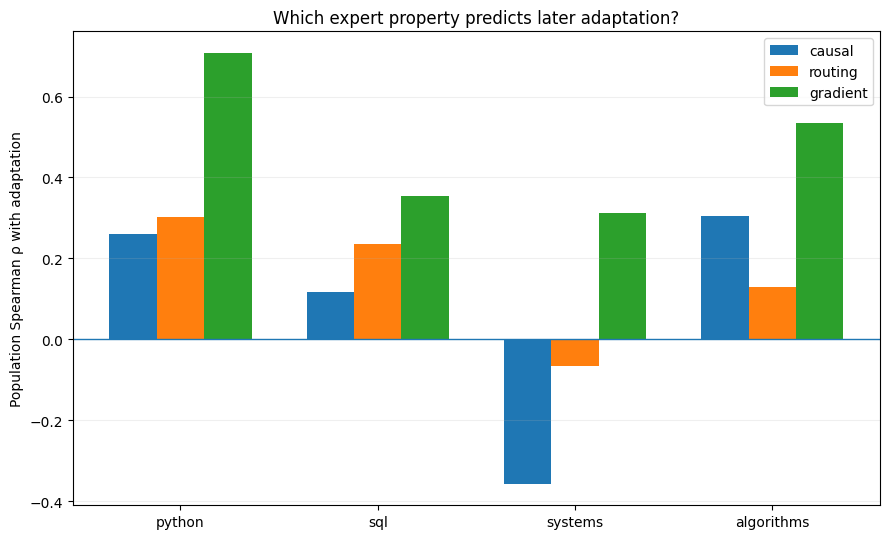

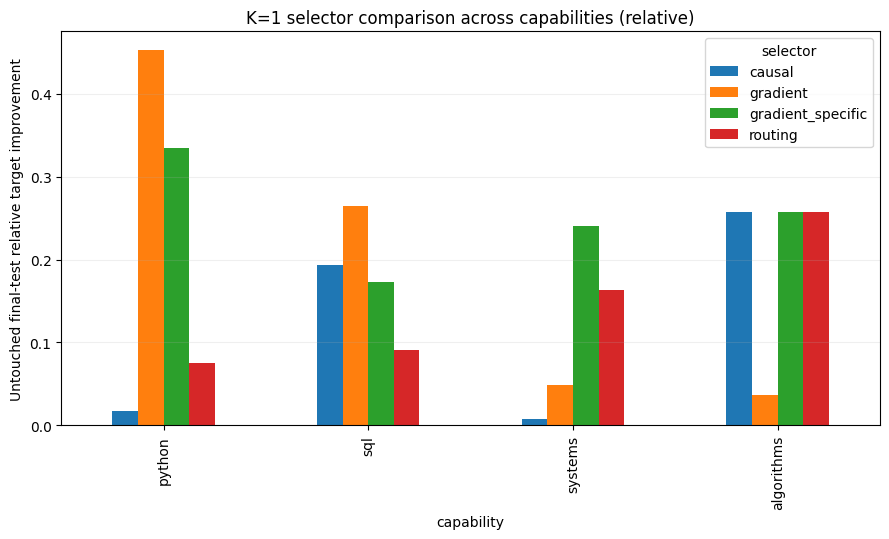

In [45]:
# Population Spearman rho by capability for the three core predictors.
core_map = {
    "causal_target_damage": "causal",
    "routing_mass": "routing",
    "precise_target_gradient": "gradient",
}

plot_df = ALL_CORR[
    (
        ALL_CORR["outcome"]
        == "target_improvement"
    )
    & (
        ALL_CORR["predictor"]
        .isin(
            core_map.keys()
        )
    )
].copy()

plot_df["short"] = (
    plot_df["predictor"]
    .map(
        core_map
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

x = np.arange(
    len(
        CAPABILITIES_TO_RUN
    )
)

width = 0.24

for i, method in enumerate(
    [
        "causal",
        "routing",
        "gradient",
    ]
):
    vals = []

    for capability in CAPABILITIES_TO_RUN:
        row = plot_df[
            (
                plot_df["capability"]
                == capability
            )
            & (
                plot_df["short"]
                == method
            )
        ]

        vals.append(
            float(
                row.iloc[0][
                    "spearman_rho"
                ]
            )
        )

    ax.bar(
        x
        + (
            i - 1
        )
        * width,
        vals,
        width=width,
        label=method,
    )

ax.axhline(
    0,
    linewidth=1,
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    CAPABILITIES_TO_RUN
)

ax.set_ylabel(
    "Population Spearman ρ with adaptation"
)

ax.set_title(
    "Which expert property predicts later adaptation?"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.2,
)

fig.tight_layout()

fig.savefig(
    RESULTS_ROOT
    / "cross_capability_predictor_rho.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Final selector mean target improvement.
pivot = ALL_FINAL.pivot(
    index="capability",
    columns="selector",
    values="relative_target_improvement_mean",
)

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

pivot.loc[
    CAPABILITIES_TO_RUN
].plot(
    kind="bar",
    ax=ax,
)

ax.set_ylabel(
    "Untouched final-test relative target improvement"
)

ax.set_title(
    "K=1 selector comparison across capabilities (relative)"
)

ax.grid(
    axis="y",
    alpha=0.2,
)

fig.tight_layout()

fig.savefig(
    RESULTS_ROOT
    / "cross_capability_k1_selectors_relative.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Automatic evidence report

In [46]:
target_meta = META_CORR[
    META_CORR["outcome"]
    == "target_improvement"
].sort_values(
    "mean_rho",
    ascending=False,
)

specific_meta = META_CORR[
    META_CORR["outcome"]
    == "specific_gain"
].sort_values(
    "mean_rho",
    ascending=False,
)

print(
    "Best mean population predictor of raw adaptation:"
)

display(
    target_meta[
        [
            "predictor",
            "mean_rho",
            "median_rho",
            "min_rho",
            "max_rho",
            "positive_count",
            "capabilities",
        ]
    ]
)

print(
    "Best mean population predictor of target-specific adaptation:"
)

display(
    specific_meta[
        [
            "predictor",
            "mean_rho",
            "median_rho",
            "min_rho",
            "max_rho",
            "positive_count",
            "capabilities",
        ]
    ]
)

print(
    "Final selector means:"
)

display(
    FINAL_META
)

if not ALL_BUDGET.empty:
    budget_meta = (
        ALL_BUDGET.groupby(
            [
                "method",
                "k",
            ]
        )
        .agg(
            target_improvement_mean=(
                "target_improvement",
                "mean",
            ),
            specific_gain_mean=(
                "specific_gain",
                "mean",
            ),
            native_target_improvement_mean=(
                "native_target_improvement",
                "mean",
            ),
            native_specific_gain_mean=(
                "native_specific_gain",
                "mean",
            ),
        )
        .reset_index()
        .sort_values(
            [
                "k",
                "target_improvement_mean",
            ],
            ascending=[
                True,
                False,
            ],
        )
    )

    budget_meta.to_csv(
        RESULTS_ROOT
        / "cross_capability_budget_meta.csv",
        index=False,
    )

    print(
        "Budget-curve means:"
    )
    display(
        budget_meta
    )

Best mean population predictor of raw adaptation:


,predictor,mean_rho,median_rho,min_rho,max_rho,positive_count,capabilities
71,precise_target_gradient,0.477180,0.444793,0.311344,0.707789,4,4
47,global_target_gradient,0.463347,0.424049,0.306227,0.699063,4,4
55,precise_control_gradient,0.321230,0.292220,0.256447,0.444034,4,4
111,target_control_gradient_cosine,0.239821,0.283007,-0.005013,0.398282,3,4
79,renorm_causal_specificity,0.161843,0.235183,-0.232432,0.409437,3,4
63,precise_gradient_specific,0.159102,0.148309,-0.027812,0.367604,2,4
103,routing_rate,0.156981,0.164369,-0.011538,0.310726,3,4
23,causal_specificity,0.151313,0.201547,-0.122298,0.324456,3,4
95,routing_mass,0.150663,0.182242,-0.065123,0.303293,3,4
7,causal_relative_specificity,0.121152,0.203044,-0.179211,0.257730,3,4


Best mean population predictor of target-specific adaptation:


,predictor,mean_rho,median_rho,min_rho,max_rho,positive_count,capabilities
14,causal_relative_target_damage,0.198553,0.190909,0.058691,0.353703,4,4
30,causal_target_damage,0.198553,0.190909,0.058691,0.353703,4,4
70,precise_target_gradient,0.195412,0.197420,-0.023096,0.409905,3,4
46,global_target_gradient,0.191626,0.183188,-0.026683,0.426811,3,4
86,renorm_causal_target_damage,0.150498,0.159823,-0.002497,0.284845,3,4
54,precise_control_gradient,0.135665,0.095261,-0.025867,0.378005,3,4
62,precise_gradient_specific,0.131050,0.140267,0.064751,0.178917,4,4
38,global_gradient_specific,0.125157,0.133042,0.083961,0.150581,4,4
110,target_control_gradient_cosine,0.100569,0.089586,-0.064271,0.287377,3,4
6,causal_relative_specificity,0.070220,0.004752,-0.083849,0.355225,2,4


Final selector means:


,selector,capabilities,target_improvement_mean,target_improvement_median,specific_gain_mean,specific_gain_median,relative_target_improvement_mean,relative_target_improvement_median,relative_specific_gain_mean,relative_specific_gain_median,native_target_improvement_mean,native_target_improvement_median,native_specific_gain_mean
2,gradient_specific,4,0.380780,0.343687,0.365763,0.309520,0.251547,0.248987,0.245498,0.251111,0.381201,0.343863,0.366278
1,gradient,4,0.189680,0.154281,0.067828,0.058868,0.200508,0.156408,0.150386,0.117782,0.189054,0.152361,0.065449
3,routing,4,0.278851,0.178065,0.289052,0.186343,0.147007,0.127557,0.151309,0.129842,0.278712,0.178610,0.288828
0,causal,4,0.219773,0.083630,0.187856,0.025924,0.118984,0.105243,0.106661,0.080026,0.220255,0.083577,0.187450


Budget-curve means:


,method,k,target_improvement_mean,specific_gain_mean,native_target_improvement_mean,native_specific_gain_mean
8,gradient_specific,1,0.376405,0.363698,0.378076,0.364096
12,routing,1,0.273904,0.285205,0.280365,0.298387
0,causal,1,0.215492,0.182910,0.217690,0.185462
4,gradient,1,0.188910,0.069938,0.189977,0.059616
9,gradient_specific,2,0.541323,0.467428,0.542269,0.461100
5,gradient,2,0.531987,0.264863,0.536945,0.263040
13,routing,2,0.382113,0.373283,0.364755,0.340486
1,causal,2,0.297944,0.194438,0.291733,0.188073
6,gradient,4,0.986512,0.408246,0.983366,0.407687
10,gradient_specific,4,0.814238,0.717954,0.817579,0.717144


# Manifest and archive

In [47]:
root_manifest = {
    "protocol_version": PROTOCOL_VERSION,
    "protocol_hash": PROTOCOL_HASH,
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "model_id": MODEL_ID,
    "experiment_csv": str(
        EXPERIMENT_CSV
    ),
    "experiment_csv_sha256": (
        sha256_file(
            EXPERIMENT_CSV
        )
    ),
    "capabilities_run": list(
        CAPABILITIES_TO_RUN
    ),
    "primary_adaptation_evaluation": "exact-baseline FP32 expert-delta adapter path",
    "secondary_deployment_audit": "trained FP32 masters cast to BF16 and merged into native Laguna experts",
    "architecture": {
        "sparse_layers": int(
            len(
                SPARSE_LAYERS
            )
        ),
        "experts_per_layer": int(
            cfg.num_experts
        ),
        "global_routed_positions": int(
            len(
                SPARSE_LAYERS
            )
            * cfg.num_experts
        ),
        "params_per_expert": int(
            params_per_expert
        ),
    },
    "protocol": {
        "population_n": int(
            POPULATION_N
        ),
        "selector_top_n": int(
            SELECTOR_TOP_N
        ),
        "global_gradient_cases_per_kind": int(
            GLOBAL_GRAD_PROBE_CASES
        ),
        "precise_gradient_cases_per_kind": int(
            PRECISE_GRAD_CASES
        ),
        "causal_top_layers": int(
            CAUSAL_TOP_LAYERS
        ),
        "causal_coalition_pool": int(
            CAUSAL_COALITION_POOL
        ),
        "causal_search_seeds": list(
            map(
                int,
                CAUSAL_SEARCH_SEEDS,
            )
        ),
        "confirm_order_seeds": list(
            map(
                int,
                CONFIRM_ORDER_SEEDS,
            )
        ),
        "budget_ks": list(
            map(
                int,
                BUDGET_KS,
            )
        ),
    },
}

atomic_write_text(
    RESULTS_ROOT
    / "manifest.json",
    json.dumps(
        root_manifest,
        indent=2,
    ),
)

archive = shutil.make_archive(
    str(
        RESULTS_ROOT
    ),
    "zip",
    root_dir=RESULTS_ROOT,
)

print(
    "Results root:",
    RESULTS_ROOT,
)

print(
    "Archive:",
    archive,
)

Results root: /home/ec2-user/workspace/laguna_xs2_v8_2_1_cross_capability_full
Archive: /home/ec2-user/workspace/laguna_xs2_v8_2_1_cross_capability_full.zip


# Final v8 validity checklist

In [48]:
checks = {}

for capability in CAPABILITIES_TO_RUN:
    cap_dir = (
        RESULTS_ROOT
        / capability
    )

    global_screen = pd.read_csv(
        cap_dir
        / "global_screen_9984.csv"
    )

    panel = pd.read_csv(
        cap_dir
        / "atlas_panel.csv"
    )

    atlas = pd.read_csv(
        cap_dir
        / "complete_crga_atlas.csv"
    )

    causal_candidates = pd.read_csv(
        cap_dir
        / "hierarchical_individual_causal.csv"
    )

    causal_greedy = pd.read_csv(
        cap_dir
        / "greedy_causal_order.csv"
    )

    selector_metrics = pd.read_csv(
        cap_dir
        / "selection_only_selector_metrics.csv"
    )

    final_df = pd.read_csv(
        cap_dir
        / "final_confirmation.csv"
    )

    validation_split = pd.read_csv(
        cap_dir
        / "atlas_validation_split.csv"
    )

    final_split = pd.read_csv(
        cap_dir
        / "untouched_final_test_split.csv"
    )

    checks[
        f"{capability}: 9984 global positions"
    ] = (
        len(
            global_screen
        )
        == len(
            SPARSE_LAYERS
        )
        * cfg.num_experts
    )

    checks[
        f"{capability}: 48 independent population experts"
    ] = (
        int(
            (
                panel[
                    "panel_group"
                ]
                == "population_random"
            ).sum()
        )
        == POPULATION_N
    )

    checks[
        f"{capability}: full panel C/R/G/A"
    ] = (
        len(
            atlas
        )
        == len(
            panel
        )
    )

    checks[
        f"{capability}: >=8 exact causal candidates"
    ] = (
        len(
            causal_candidates
        )
        >= max(
            BUDGET_KS
        )
    )

    checks[
        f"{capability}: 8-step greedy causal coalition"
    ] = (
        len(
            causal_greedy
        )
        == max(
            BUDGET_KS
        )
    )

    checks[
        f"{capability}: selection selector table has no validation columns"
    ] = (
        not any(
            str(
                col
            ).startswith(
                "validation_"
            )
            for col in (
                selector_metrics.columns
            )
        )
    )

    checks[
        f"{capability}: validation/final IDs disjoint"
    ] = (
        set(
            validation_split[
                "example_id"
            ]
        )
        .isdisjoint(
            set(
                final_split[
                    "example_id"
                ]
            )
        )
    )

    checks[
        f"{capability}: validation has 25+25"
    ] = (
        len(
            validation_split
        )
        == 50
        and int(
            (
                validation_split[
                    "kind"
                ]
                == "target"
            ).sum()
        )
        == 25
        and int(
            (
                validation_split[
                    "kind"
                ]
                == "control"
            ).sum()
        )
        == 25
    )

    checks[
        f"{capability}: final test has 25+25"
    ] = (
        len(
            final_split
        )
        == 50
        and int(
            (
                final_split[
                    "kind"
                ]
                == "target"
            ).sum()
        )
        == 25
        and int(
            (
                final_split[
                    "kind"
                ]
                == "control"
            ).sum()
        )
        == 25
    )

    checks[
        f"{capability}: 4 selectors x 3 seeds"
    ] = (
        len(
            final_df
        )
        == 4
        * len(
            CONFIRM_ORDER_SEEDS
        )
    )

    checks[
        f"{capability}: post-training adapter/native audit finite"
    ] = bool(
        np.isfinite(
            final_df[
                "delta_merge_max_nll_diff"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    )

    panel_adapt_df = pd.read_csv(
        cap_dir
        / "panel_adaptation_validation.csv"
    )

    checks[
        f"{capability}: panel adapter/native audit finite"
    ] = bool(
        np.isfinite(
            panel_adapt_df[
                "delta_merge_max_nll_diff"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    )

    if RUN_BUDGET_CURVES:
        budget_df = pd.read_csv(
            cap_dir
            / "budget_curve.csv"
        )

        checks[
            f"{capability}: 4 methods x {len(BUDGET_KS)} budgets"
        ] = (
            len(
                budget_df
            )
            == 4
            * len(
                BUDGET_KS
            )
        )

        checks[
            f"{capability}: budget adapter/native audit finite"
        ] = bool(
            np.isfinite(
                budget_df[
                    "delta_merge_max_nll_diff"
                ].to_numpy(
                    dtype=np.float64
                )
            ).all()
        )

checks[
    "correct Laguna newline teacher forcing retained"
] = True

checks[
    "exact token-level teacher-forcing alignment checked"
] = True

checks[
    "selectors frozen before validation adaptation"
] = True

checks[
    "final test never used for selector construction"
] = True

checks[
    "gradient K rankings use precise selection-only reranking"
] = True

checks[
    "causal K rankings use greedy joint interventions"
] = True

checks[
    "surgical-bank exact-baseline equivalence checked"
] = True

checks[
    "native BF16 merge roundtrip checked at initialization"
] = True

checks[
    "frozen base restored after every training arm"
] = True

for (
    name,
    passed,
) in checks.items():
    print(
        "PASS"
        if passed
        else "FAIL",
        "-",
        name,
    )

if not all(
    checks.values()
):
    raise RuntimeError(
        "One or more v8.2 validity checks failed."
    )

print(
    "\nV8.2 validity checklist: PASS"
)


PASS - python: 9984 global positions
PASS - python: 48 independent population experts
PASS - python: full panel C/R/G/A
PASS - python: >=8 exact causal candidates
PASS - python: 8-step greedy causal coalition
PASS - python: selection selector table has no validation columns
PASS - python: validation/final IDs disjoint
PASS - python: validation has 25+25
PASS - python: final test has 25+25
PASS - python: 4 selectors x 3 seeds
PASS - python: post-training adapter/native audit finite
PASS - python: panel adapter/native audit finite
PASS - python: 4 methods x 4 budgets
PASS - python: budget adapter/native audit finite
PASS - sql: 9984 global positions
PASS - sql: 48 independent population experts
PASS - sql: full panel C/R/G/A
PASS - sql: >=8 exact causal candidates
PASS - sql: 8-step greedy causal coalition
PASS - sql: selection selector table has no validation columns
PASS - sql: validation/final IDs disjoint
PASS - sql: validation has 25+25
PASS - sql: final test has 25+25
PASS - sql: 4